#Анализ

In [ ]:
import torch
import numpy as np
from transformers import AutoModelForCausalLM, AutoTokenizer
from torch.utils.data import DataLoader, Dataset
from tqdm import tqdm
import math
from torch.nn.utils.rnn import pad_sequence

class TextDataset(Dataset):
    def __init__(self, texts, tokenizer, max_length=512):
        self.texts = texts
        self.tokenizer = tokenizer
        self.max_length = max_length

    def __len__(self):
        return len(self.texts)

    def __getitem__(self, idx):
        text = self.texts[idx]
        # Токенизируем без возврата тензоров сразу
        encodings = self.tokenizer(
            text,
            truncation=True,
            max_length=self.max_length,
            return_tensors=None  # Не возвращаем тензоры здесь
        )
        return {
            'input_ids': torch.tensor(encodings['input_ids']),
            'attention_mask': torch.tensor(encodings['attention_mask'])
        }

def collate_fn(batch):
    """Функция для паддинга последовательностей разной длины"""
    input_ids = [item['input_ids'] for item in batch]
    attention_masks = [item['attention_mask'] for item in batch]

    # Паддинг до максимальной длины в батче
    padded_input_ids = pad_sequence(input_ids, batch_first=True, padding_value=0)
    padded_attention_masks = pad_sequence(attention_masks, batch_first=True, padding_value=0)

    return {
        'input_ids': padded_input_ids,
        'attention_mask': padded_attention_masks
    }

def estimate_dataset_complexity(texts, model_name="gpt2", batch_size=4, max_length=512):
    """
    Оценивает информационную сложность датасета в битах
    """

    # Загружаем модель и токенизатор
    print(f"Загрузка модели {model_name}...")
    tokenizer = AutoTokenizer.from_pretrained(model_name)
    tokenizer.pad_token = tokenizer.eos_token  # Важно: устанавливаем pad_token

    model = AutoModelForCausalLM.from_pretrained(model_name)
    model.eval()

    if torch.cuda.is_available():
        model = model.cuda()
        print("Используется GPU")

    # Создаем даталоадер с кастомной функцией коллации
    dataset = TextDataset(texts, tokenizer, max_length)
    dataloader = DataLoader(
        dataset,
        batch_size=batch_size,
        shuffle=False,
        collate_fn=collate_fn  # Используем нашу функцию паддинга
    )

    total_loss = 0.0
    total_tokens = 0

    print("Оценка сложности датасета...")
    with torch.no_grad():
        for batch in tqdm(dataloader):
            input_ids = batch['input_ids']
            attention_mask = batch['attention_mask']

            if torch.cuda.is_available():
                input_ids = input_ids.cuda()
                attention_mask = attention_mask.cuda()

            # Вычисляем loss (кросс-энтропия в натах)
            outputs = model(input_ids, attention_mask=attention_mask, labels=input_ids)
            loss = outputs.loss  # Это loss в натах (natural log)

            # Количество реальных токенов в батче (исключая паддинг)
            num_tokens = attention_mask.sum().item()

            total_loss += loss.item() * num_tokens
            total_tokens += num_tokens

    # Средняя кросс-энтропия (в натах на токен)
    avg_cross_entropy_nats = total_loss / total_tokens

    # Переводим в биты
    avg_cross_entropy_bits = avg_cross_entropy_nats / math.log(2)

    # Общая сложность датасета
    total_complexity_bits = total_tokens * avg_cross_entropy_bits

    # Дополнительные метрики
    perplexity = math.exp(avg_cross_entropy_nats)

    return {
        'total_tokens': total_tokens,
        'avg_complexity_bits_per_token': avg_cross_entropy_bits,
        'total_complexity_bits': total_complexity_bits,
        'avg_cross_entropy_nats': avg_cross_entropy_nats,
        'perplexity': perplexity,
        'total_complexity_megabits': total_complexity_bits / (1024 * 1024),
        'total_complexity_gigabits': total_complexity_bits / (1024 * 1024 * 1024)
    }

# Загрузка датасета AG News
def load_ag_news():
    """Загружает AG News из библиотеки datasets"""
    try:
        from datasets import load_dataset
        print("Загрузка датасета AG News...")
        dataset = load_dataset("ag_news", split="train")
        # Берем только текст (без меток)
        texts = [example["text"] for example in dataset]
        print(f"Загружено {len(texts)} примеров")
        return texts
    except ImportError:
        print("Библиотека datasets не установлена. Установите: pip install datasets")
        # Альтернативная загрузка через huggingface hub
        import pandas as pd
        url = "https://raw.githubusercontent.com/mhjabreel/CharCnn_Keras/master/data/ag_news_csv/train.csv"
        df = pd.read_csv(url, names=["label", "title", "description"])
        texts = (df["title"] + ". " + df["description"]).tolist()
        print(f"Загружено {len(texts)} примеров (альтернативный источник)")
        return texts

# Запуск
if __name__ == "__main__":
    # Загружаем AG News
    texts = load_ag_news()

    # Для быстрого теста можно взять только первые 1000 примеров
    # texts = texts[:1000]  # Раскомментируйте для быстрого теста

    # Оцениваем сложность
    metrics = estimate_dataset_complexity(
        texts=texts,
        model_name="gpt2",
        batch_size=4,  # Уменьшите до 2, если не хватает памяти
        max_length=256  # Уменьшил с 512 для экономии памяти
    )

    # Выводим результаты
    print("\n" + "="*50)
    print("РЕЗУЛЬТАТЫ ОЦЕНКИ СЛОЖНОСТИ ДАТАСЕТА AG NEWS")
    print("="*50)
    print(f"Всего токенов: {metrics['total_tokens']:,}")
    print(f"Средняя сложность: {metrics['avg_complexity_bits_per_token']:.3f} бит на токен")
    print(f"Средняя кросс-энтропия: {metrics['avg_cross_entropy_nats']:.3f} нат на токен")
    print(f"Перплексия: {metrics['perplexity']:.2f}")
    print(f"\nОбщая информационная сложность датасета:")
    print(f"  - {metrics['total_complexity_bits']:,.0f} бит")
    print(f"  - {metrics['total_complexity_megabits']:.2f} мегабит")
    print(f"  - {metrics['total_complexity_gigabits']:.4f} гигабит")

    # Теоретическая оценка емкости LoRA для справки
    print("\n" + "="*50)
    print("ДЛЯ СРАВНЕНИЯ С ЕМКОСТЬЮ LORA")
    print("="*50)
    for rank in [4, 8, 16, 32]:
        # Для GPT-2 (n_embd=768, n_layer=12)
        lora_params = 2 * 768 * rank * 12
        lora_capacity_bits = lora_params * 2  # 2 бита на параметр
        ratio = metrics['total_complexity_bits'] / lora_capacity_bits
        print(f"LoRA r={rank}: {lora_params:,} парам., емкость {lora_capacity_bits:,.0f} бит → отношение сложность/емкость = {ratio:.2f}")

Загрузка датасета AG News...


README.md: 0.00B [00:00, ?B/s]

data/train-00000-of-00001.parquet:   0%|          | 0.00/18.6M [00:00<?, ?B/s]

data/test-00000-of-00001.parquet:   0%|          | 0.00/1.23M [00:00<?, ?B/s]

Generating train split:   0%|          | 0/120000 [00:00<?, ? examples/s]

...

Loading weights:   0%|          | 0/148 [00:00<?, ?it/s]

GPT2LMHeadModel LOAD REPORT from: gpt2
Key                  | Status     |  | 
---------------------+------------+--+-
h.{0...11}.attn.bias | UNEXPECTED |  | 

Notes:
- UNEXPECTED	:can be ignored when loading from different task/architecture; not ok if you expect identical arch.


Используется GPU
Оценка сложности датасета...


100%|██████████| 30000/30000 [14:34<00:00, 34.29it/s]


РЕЗУЛЬТАТЫ ОЦЕНКИ СЛОЖНОСТИ ДАТАСЕТА AG NEWS
Всего токенов: 6,251,092
Средняя сложность: 8.041 бит на токен
Средняя кросс-энтропия: 5.573 нат на токен
Перплексия: 263.33

Общая информационная сложность датасета:
  - 50,263,334 бит
  - 47.93 мегабит
  - 0.0468 гигабит

ДЛЯ СРАВНЕНИЯ С ЕМКОСТЬЮ LORA
LoRA r=4: 73,728 парам., емкость 147,456 бит → отношение сложность/емкость = 340.87
LoRA r=8: 147,456 парам., емкость 294,912 бит → отношение сложность/емкость = 170.44
LoRA r=16: 294,912 парам., емкость 589,824 бит → отношение сложность/емкость = 85.22
LoRA r=32: 589,824 парам., емкость 1,179,648 бит → отношение сложность/емкость = 42.61


In [ ]:
import torch
import os
import json
import pandas as pd
from transformers import AutoModelForCausalLM, AutoTokenizer
from torch.utils.data import DataLoader, Dataset
from tqdm import tqdm
import math
from torch.nn.utils.rnn import pad_sequence

class TextDataset(Dataset):
    def __init__(self, texts, tokenizer, max_length=512):
        self.texts = texts
        self.tokenizer = tokenizer
        self.max_length = max_length

    def __len__(self):
        return len(self.texts)

    def __getitem__(self, idx):
        text = self.texts[idx]
        # Токенизируем без возврата тензоров сразу
        encodings = self.tokenizer(
            text,
            truncation=True,
            max_length=self.max_length,
            return_tensors=None
        )
        return {
            'input_ids': torch.tensor(encodings['input_ids']),
            'attention_mask': torch.tensor(encodings['attention_mask'])
        }

def collate_fn(batch):
    """Функция для паддинга последовательностей разной длины"""
    input_ids = [item['input_ids'] for item in batch]
    attention_masks = [item['attention_mask'] for item in batch]

    # Паддинг до максимальной длины в батче
    padded_input_ids = pad_sequence(input_ids, batch_first=True, padding_value=0)
    padded_attention_masks = pad_sequence(attention_masks, batch_first=True, padding_value=0)

    return {
        'input_ids': padded_input_ids,
        'attention_mask': padded_attention_masks
    }

def estimate_dataset_complexity(texts, model_name="gpt2", batch_size=4, max_length=512):
    """
    Оценивает информационную сложность датасета в битах
    """

    # Загружаем модель и токенизатор
    print(f"Загрузка модели {model_name}...")
    tokenizer = AutoTokenizer.from_pretrained(model_name)
    tokenizer.pad_token = tokenizer.eos_token

    model = AutoModelForCausalLM.from_pretrained(model_name)
    model.eval()

    if torch.cuda.is_available():
        model = model.cuda()
        print("Используется GPU")

    # Создаем даталоадер с кастомной функцией коллации
    dataset = TextDataset(texts, tokenizer, max_length)
    dataloader = DataLoader(
        dataset,
        batch_size=batch_size,
        shuffle=False,
        collate_fn=collate_fn
    )

    total_loss = 0.0
    total_tokens = 0

    print("Оценка сложности датасета...")
    with torch.no_grad():
        for batch in tqdm(dataloader):
            input_ids = batch['input_ids']
            attention_mask = batch['attention_mask']

            if torch.cuda.is_available():
                input_ids = input_ids.cuda()
                attention_mask = attention_mask.cuda()

            # Вычисляем loss
            outputs = model(input_ids, attention_mask=attention_mask, labels=input_ids)
            loss = outputs.loss

            # Количество реальных токенов в батче (исключая паддинг)
            num_tokens = attention_mask.sum().item()

            total_loss += loss.item() * num_tokens
            total_tokens += num_tokens

    # Средняя кросс-энтропия (в натах на токен)
    avg_cross_entropy_nats = total_loss / total_tokens

    # Переводим в биты
    avg_cross_entropy_bits = avg_cross_entropy_nats / math.log(2)

    # Общая сложность датасета
    total_complexity_bits = total_tokens * avg_cross_entropy_bits

    # Дополнительные метрики
    perplexity = math.exp(avg_cross_entropy_nats)

    return {
        'total_tokens': total_tokens,
        'avg_complexity_bits_per_token': avg_cross_entropy_bits,
        'total_complexity_bits': total_complexity_bits,
        'avg_cross_entropy_nats': avg_cross_entropy_nats,
        'perplexity': perplexity,
        'total_complexity_megabits': total_complexity_bits / (1024 * 1024),
        'total_complexity_gigabits': total_complexity_bits / (1024 * 1024 * 1024)
    }

# ============================================================
# ФУНКЦИИ ДЛЯ ЗАГРУЗКИ ВАШЕГО ДАТАСЕТА
# ============================================================

def load_dataset_from_file(file_path, text_column=None, max_samples=None):
    """
    Универсальная загрузка датасета из различных форматов

    Args:
        file_path: путь к файлу (.txt, .csv, .json, .jsonl, .xlsx)
        text_column: название колонки с текстом (для CSV/Excel)
        max_samples: максимальное количество примеров для загрузки (опционально)

    Returns:
        list: список текстов
    """
    file_ext = os.path.splitext(file_path)[1].lower()

    texts = []

    # TXT файл (каждая строка - отдельный текст)
    if file_ext == '.txt':
        print(f"Загрузка из TXT файла: {file_path}")
        with open(file_path, 'r', encoding='utf-8') as f:
            texts = [line.strip() for line in f if line.strip()]

    # CSV файл
    elif file_ext == '.csv':
        print(f"Загрузка из CSV файла: {file_path}")
        df = pd.read_csv(file_path)
        if text_column:
            texts = df[text_column].astype(str).tolist()
        else:
            # Если колонка не указана, берем первую строковую колонку
            for col in df.columns:
                if df[col].dtype == 'object':
                    texts = df[col].astype(str).tolist()
                    print(f"  Использована колонка: {col}")
                    break
            if not texts:
                raise ValueError("Не найдена текстовая колонка в CSV. Укажите text_column.")

    # Excel файл
    elif file_ext in ['.xlsx', '.xls']:
        print(f"Загрузка из Excel файла: {file_path}")
        df = pd.read_excel(file_path)
        if text_column:
            texts = df[text_column].astype(str).tolist()
        else:
            for col in df.columns:
                if df[col].dtype == 'object':
                    texts = df[col].astype(str).tolist()
                    print(f"  Использована колонка: {col}")
                    break

    # JSON файл (массив строк или объекты с полем text)
    elif file_ext == '.json':
        print(f"Загрузка из JSON файла: {file_path}")
        with open(file_path, 'r', encoding='utf-8') as f:
            data = json.load(f)
        if isinstance(data, list):
            if all(isinstance(item, str) for item in data):
                texts = data
            elif all(isinstance(item, dict) for item in data):
                if text_column:
                    texts = [item[text_column] for item in data if text_column in item]
                else:
                    # Пробуем найти поле 'text', 'content', 'body'
                    for key in ['text', 'content', 'body', 'sentence']:
                        if key in data[0]:
                            texts = [item[key] for item in data if key in item]
                            print(f"  Использовано поле: {key}")
                            break
        elif isinstance(data, dict) and 'data' in data:
            texts = [item.get(text_column or 'text', str(item)) for item in data['data']]

    # JSONL файл (построчный JSON)
    elif file_ext == '.jsonl':
        print(f"Загрузка из JSONL файла: {file_path}")
        with open(file_path, 'r', encoding='utf-8') as f:
            for line in f:
                if line.strip():
                    item = json.loads(line)
                    if isinstance(item, str):
                        texts.append(item)
                    elif text_column and text_column in item:
                        texts.append(item[text_column])
                    elif 'text' in item:
                        texts.append(item['text'])
                    else:
                        texts.append(str(item))

    else:
        raise ValueError(f"Неподдерживаемый формат файла: {file_ext}. Используйте .txt, .csv, .json, .jsonl, .xlsx")

    # Ограничиваем количество примеров, если указано
    if max_samples and max_samples < len(texts):
        texts = texts[:max_samples]
        print(f"  Ограничено до {max_samples} примеров")

    print(f"  Загружено {len(texts)} текстов")

    # Статистика по длинам
    lengths = [len(t.split()) for t in texts]
    print(f"  Статистика: мин={min(lengths)}, макс={max(lengths)}, средняя={sum(lengths)/len(lengths):.1f} слов")

    return texts


def load_dataset_from_folder(folder_path, max_samples=None):
    """
    Загрузка всех текстовых файлов из папки

    Args:
        folder_path: путь к папке с текстовыми файлами
        max_samples: максимальное количество примеров

    Returns:
        list: список текстов
    """
    texts = []
    print(f"Загрузка из папки: {folder_path}")

    for filename in os.listdir(folder_path):
        if filename.endswith(('.txt', '.md', '.json')):
            file_path = os.path.join(folder_path, filename)
            with open(file_path, 'r', encoding='utf-8') as f:
                content = f.read()
                if content.strip():
                    texts.append(content.strip())

    if max_samples and max_samples < len(texts):
        texts = texts[:max_samples]

    print(f"  Загружено {len(texts)} файлов")
    return texts


# ============================================================
# ОСНОВНОЙ ЗАПУСК
# ============================================================

if __name__ == "__main__":

    # ========================================================
    # НАСТРОЙКИ - ИЗМЕНИТЕ ЭТО ПОД ВАШ ДАТАСЕТ
    # ========================================================

    # СПОСОБ 1: Загрузка из одного файла
    # Укажите путь к вашему файлу
    DATA_SOURCE = "result.csv"  # <-- ИЗМЕНИТЕ ЗДЕСЬ

    # Если файл CSV/Excel/JSON, укажите название колонки с текстом
    TEXT_COLUMN = "text"  # <-- ИЗМЕНИТЕ (например: "content", "sentence", "review")

    # Формат файла определится автоматически по расширению

    # ========================================================
    # Альтернативный способ - раскомментируйте нужный блок
    # ========================================================

    # СПОСОБ 2: Загрузка из папки с текстовыми файлами
    # DATA_SOURCE = "path/to/your/folder"  # <-- РАСКОММЕНТИРУЙТЕ
    # texts = load_dataset_from_folder(DATA_SOURCE, max_samples=None)

    # СПОСОБ 3: Прямое указание списка текстов (для теста)
    # texts = [
    #     "Первый текст вашего датасета",
    #     "Второй текст для оценки сложности",
    #     "Третий пример текстовых данных"
    # ]

    # ========================================================
    # ЗАГРУЗКА И ОЦЕНКА
    # ========================================================

    # Загружаем датасет
    texts = load_dataset_from_file(DATA_SOURCE, text_column=TEXT_COLUMN, max_samples=None)

    # Для быстрого теста можно взять только часть датасета
    # texts = texts[:500]  # РАСКОММЕНТИРУЙТЕ ДЛЯ ТЕСТА

    if len(texts) == 0:
        print("Ошибка: не найдено текстов для анализа!")
        exit()

    # Оцениваем сложность
    metrics = estimate_dataset_complexity(
        texts=texts,
        model_name="gpt2",  # можно заменить на "meta-llama/Llama-2-7b-hf" или другую
        batch_size=4,       # уменьшите до 2 при нехватке памяти
        max_length=256      # уменьшите при нехватке памяти
    )

    # Выводим результаты
    print("\n" + "="*60)
    print("РЕЗУЛЬТАТЫ ОЦЕНКИ СЛОЖНОСТИ ДАТАСЕТА")
    print("="*60)
    print(f"Всего токенов: {metrics['total_tokens']:,}")
    print(f"Средняя сложность: {metrics['avg_complexity_bits_per_token']:.3f} бит на токен")
    print(f"Средняя кросс-энтропия: {metrics['avg_cross_entropy_nats']:.3f} нат на токен")
    print(f"Перплексия: {metrics['perplexity']:.2f}")
    print(f"\nОбщая информационная сложность датасета:")
    print(f"  - {metrics['total_complexity_bits']:,.0f} бит")
    print(f"  - {metrics['total_complexity_megabits']:.2f} мегабит")
    print(f"  - {metrics['total_complexity_gigabits']:.4f} гигабит")

    # Сравнение с емкостью LoRA (полезно для диплома)
    print("\n" + "="*60)
    print("СРАВНЕНИЕ С ЕМКОСТЬЮ LORA (для модели GPT-2)")
    print("="*60)

    # Параметры GPT-2: hidden_size=768, num_layers=12
    HIDDEN_SIZE = 768
    NUM_LAYERS = 12

    for rank in [4, 8, 16, 32, 64]:
        lora_params = 2 * HIDDEN_SIZE * rank * NUM_LAYERS
        lora_capacity_bits = lora_params * 2  # 2 бита на параметр
        ratio = metrics['total_complexity_bits'] / lora_capacity_bits
        recommendation = "✅ достаточно" if ratio < 1.0 else "⚠️ может не хватить"
        print(f"LoRA r={rank:2d}: {lora_params:>8,} парам. → емкость {lora_capacity_bits:>10,.0f} бит → отношение {ratio:.2f} {recommendation}")

    print("\n" + "="*60)
    print("РЕКОМЕНДАЦИЯ ПО ВЫБОРУ РАНГА LORA")
    print("="*60)

    # Находим минимальный подходящий ранг
    optimal_rank = 4
    for rank in [4, 8, 16, 32, 64]:
        lora_params = 2 * HIDDEN_SIZE * rank * NUM_LAYERS
        lora_capacity_bits = lora_params * 2
        if metrics['total_complexity_bits'] <= lora_capacity_bits:
            optimal_rank = rank
            break

    print(f"Рекомендуемый минимальный ранг LoRA: r = {optimal_rank}")
    print(f"(исходя из оценки емкости 2 бита на параметр)")

Загрузка из CSV файла: result.csv
  Загружено 41060 текстов
  Статистика: мин=1, макс=134, средняя=14.7 слов
Загрузка модели gpt2...


/usr/local/lib/python3.12/dist-packages/huggingface_hub/utils/_auth.py:103: UserWarning: 
Error while fetching `HF_TOKEN` secret value from your vault: 'Requesting secret HF_TOKEN timed out. Secrets can only be fetched when running from the Colab UI.'.
You are not authenticated with the Hugging Face Hub in this notebook.
If the error persists, please let us know by opening an issue on GitHub (https://github.com/huggingface/huggingface_hub/issues/new).
  warnings.warn(


config.json:   0%|          | 0.00/665 [00:00<?, ?B/s]

tokenizer_config.json:   0%|          | 0.00/26.0 [00:00<?, ?B/s]

vocab.json: 0.00B [00:00, ?B/s]

...

GPT2LMHeadModel LOAD REPORT from: gpt2
Key                  | Status     |  | 
---------------------+------------+--+-
h.{0...11}.attn.bias | UNEXPECTED |  | 

Notes:
- UNEXPECTED	:can be ignored when loading from different task/architecture; not ok if you expect identical arch.


generation_config.json:   0%|          | 0.00/124 [00:00<?, ?B/s]

Используется GPU
Оценка сложности датасета...


100%|██████████| 10265/10265 [11:02<00:00, 15.50it/s]


РЕЗУЛЬТАТЫ ОЦЕНКИ СЛОЖНОСТИ ДАТАСЕТА
Всего токенов: 4,537,655
Средняя сложность: 6.170 бит на токен
Средняя кросс-энтропия: 4.276 нат на токен
Перплексия: 71.99

Общая информационная сложность датасета:
  - 27,995,782 бит
  - 26.70 мегабит
  - 0.0261 гигабит

СРАВНЕНИЕ С ЕМКОСТЬЮ LORA (для модели GPT-2)
LoRA r= 4:   73,728 парам. → емкость    147,456 бит → отношение 189.86 ⚠️ может не хватить
LoRA r= 8:  147,456 парам. → емкость    294,912 бит → отношение 94.93 ⚠️ может не хватить
LoRA r=16:  294,912 парам. → емкость    589,824 бит → отношение 47.46 ⚠️ может не хватить
LoRA r=32:  589,824 парам. → емкость  1,179,648 бит → отношение 23.73 ⚠️ может не хватить
LoRA r=64: 1,179,648 парам. → емкость  2,359,296 бит → отношение 11.87 ⚠️ может не хватить

РЕКОМЕНДАЦИЯ ПО ВЫБОРУ РАНГА LORA
Рекомендуемый минимальный ранг LoRA: r = 4
(исходя из оценки емкости 2 бита на параметр)


##**Метод OrthoGeoLoRA**

Для исследования OrthoGeoLoRA отберем данные только по модели Qwen3, т.к. в исследовании представлен этот метот только для этой модели, т.к. для Qwen2.5-1.5 наблюдался развал обучения.

Также, важно взять одинаковые выборки для кажной вариации

###**RU**

In [ ]:
df_sub = pd.read_csv('all_exp_results.csv')
df_sub = df_sub[df_sub['model'] == "qwen3"]
df_sub = df_sub[df_sub['dataset'] == "RU"]
df_sub = df_sub[df_sub['pst_dataset'] < 8212]
# добавляем режим данных
df_sub["data_regime"] = np.where(df_sub["pst_dataset"] < 1500, "low", "high")

In [ ]:
summary = df_sub.groupby(["data_regime", "method"])["accuracy"].agg(
    ["mean", "std", "count"]
).reset_index()

print(summary)

  data_regime     method      mean       std  count
0        high       LoRA  0.894568  0.016543     36
1        high     OGLoRA  0.899145  0.010083     36
2        high  QLoRA fp4  0.886680  0.016158     36
3        high  QLoRA nf4  0.891436  0.014904     36
4        high   baseline  0.733277  0.071944      3
5         low       LoRA  0.638618  0.160498     12
6         low     OGLoRA  0.776709  0.093475     12
7         low  QLoRA fp4  0.619307  0.153786     12
8         low  QLoRA nf4  0.640516  0.158731     12
9         low   baseline  0.468095       NaN      1


In [ ]:
from scipy.stats import mannwhitneyu

methods = df_sub["method"].unique()
methods = [m for m in methods if m != "OGLoRA"]

results = []

for regime in ["low", "high"]:
    og = df_sub[(df_sub["method"] == "OGLoRA") & (df_sub["data_regime"] == regime)]["accuracy"]

    for m in methods:
        other = df_sub[(df_sub["method"] == m) & (df_sub["data_regime"] == regime)]["accuracy"]

        stat, p = mannwhitneyu(og, other, alternative="two-sided")

        results.append({
            "regime": regime,
            "compare": f"OGLoRA vs {m}",
            "mean_diff": og.mean() - other.mean(),
            "p_value": p
        })

results_df = pd.DataFrame(results)
print(results_df)

  regime              compare  mean_diff   p_value
0    low   OGLoRA vs baseline   0.308613  0.153846
1    low       OGLoRA vs LoRA   0.138091  0.019373
2    low  OGLoRA vs QLoRA nf4   0.136193  0.026229
3    low  OGLoRA vs QLoRA fp4   0.157402  0.006099
4   high   OGLoRA vs baseline   0.165868  0.004800
5   high       OGLoRA vs LoRA   0.004577  0.367570
6   high  OGLoRA vs QLoRA nf4   0.007709  0.021579
7   high  OGLoRA vs QLoRA fp4   0.012465  0.000568


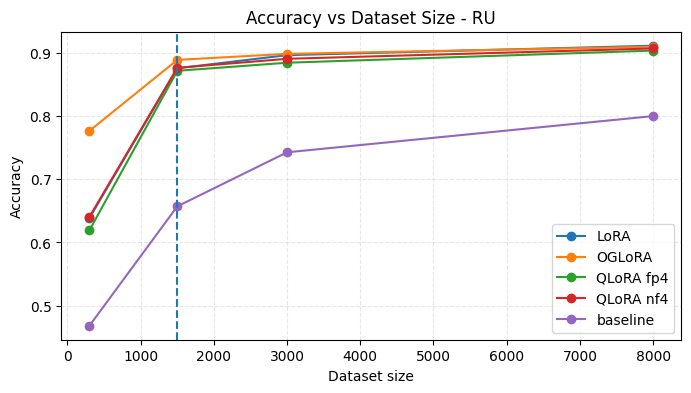

In [ ]:
import matplotlib.pyplot as plt

pivot = df_sub.groupby(["pst_dataset", "method"])["accuracy"].mean().unstack()

plt.figure(figsize=(8, 4))
for method in pivot.columns:
    plt.plot(pivot.index, pivot[method], marker="o", label=method)

plt.axvline(1500, linestyle="--")  # граница режимов

plt.xlabel("Dataset size")
plt.ylabel("Accuracy")
plt.title("Accuracy vs Dataset Size - RU")
plt.grid(True, linestyle="--", alpha=0.3)
plt.legend()
plt.grid(True)
plt.show()

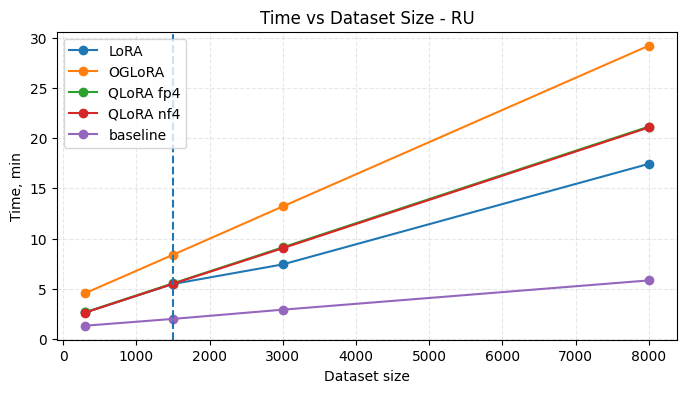

In [ ]:
import matplotlib.pyplot as plt

pivot = df_sub.groupby(["pst_dataset", "method"])["time"].mean().unstack()

plt.figure(figsize=(8, 4))
for method in pivot.columns:
    plt.plot(pivot.index, pivot[method], marker="o", label=method)

plt.axvline(1500, linestyle="--")  # граница режимов

plt.xlabel("Dataset size")
plt.ylabel("Time, min")
plt.title("Time vs Dataset Size - RU")
plt.grid(True, linestyle="--", alpha=0.3)
plt.legend()
plt.grid(True)
plt.show()

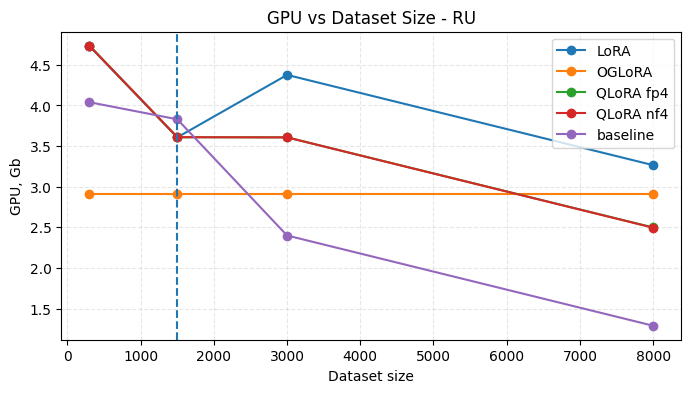

In [ ]:
import matplotlib.pyplot as plt

pivot = df_sub.groupby(["pst_dataset", "method"])["gpu"].mean().unstack()

plt.figure(figsize=(8, 4))
for method in pivot.columns:
    plt.plot(pivot.index, pivot[method], marker="o", label=method)

plt.axvline(1500, linestyle="--")  # граница режимов

plt.xlabel("Dataset size")
plt.ylabel("GPU, Gb")
plt.title("GPU vs Dataset Size - RU")
plt.grid(True, linestyle="--", alpha=0.3)
plt.legend()
plt.grid(True)
plt.show()

<Figure size 640x480 with 0 Axes>

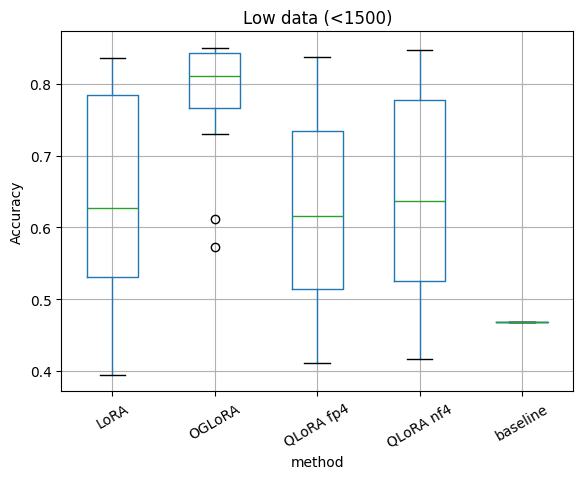

<Figure size 640x480 with 0 Axes>

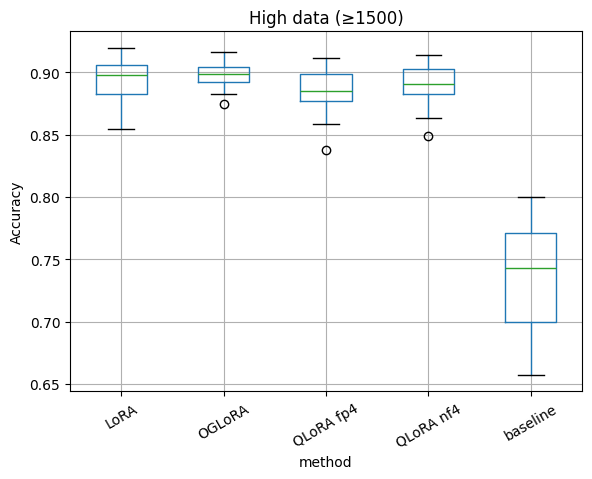

In [ ]:
import matplotlib.pyplot as plt

low = df_sub[df_sub["data_regime"] == "low"]
high = df_sub[df_sub["data_regime"] == "high"]

# low data
plt.figure()
low.boxplot(column="accuracy", by="method")
plt.title("Low data (<1500)")
plt.suptitle("")
plt.ylabel("Accuracy")
plt.xticks(rotation=30)
plt.grid(True)
plt.show()

# high data
plt.figure()
high.boxplot(column="accuracy", by="method")
plt.title("High data (≥1500)")
plt.suptitle("")
plt.ylabel("Accuracy")
plt.xticks(rotation=30)
plt.grid(True)
plt.show()

In [ ]:
means = df_sub.groupby(["data_regime", "method"])["accuracy"].mean().unstack()

diff_low = means.loc["low"] - means.loc["low"].drop("OGLoRA").mean()
diff_high = means.loc["high"] - means.loc["high"].drop("OGLoRA").mean()

print("OGLoRA advantage (low):", diff_low["OGLoRA"])
print("OGLoRA advantage (high):", diff_high["OGLoRA"])

OGLoRA advantage (low): 0.1850746875624999
OGLoRA advantage (high): 0.043678458401041675


Метод OGLoRA демонстрирует преимущество в условиях ограниченного объёма данных, обеспечивая более высокое качество по сравнению с альтернативными подходами. Однако при увеличении размера обучающей выборки различия между методами сглаживаются, что указывает на преимущество OGLoRA именно в low-data режиме.

<Figure size 640x480 with 0 Axes>

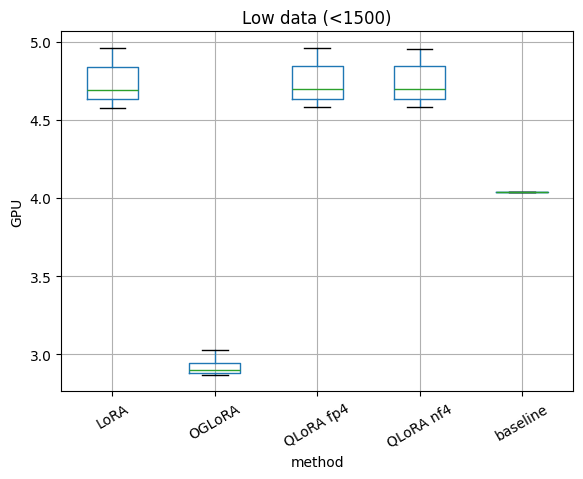

<Figure size 640x480 with 0 Axes>

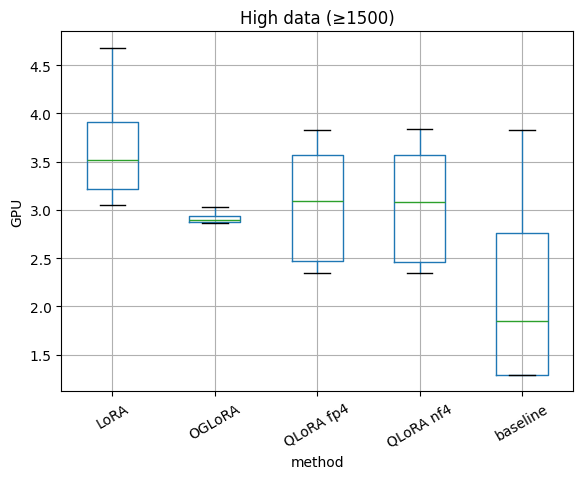

In [ ]:
import matplotlib.pyplot as plt

low = df_sub[df_sub["data_regime"] == "low"]
high = df_sub[df_sub["data_regime"] == "high"]

# low data
plt.figure()
low.boxplot(column="gpu", by="method")
plt.title("Low data (<1500)")
plt.suptitle("")
plt.ylabel("GPU")
plt.xticks(rotation=30)
plt.grid(True)
plt.show()

# high data
plt.figure()
high.boxplot(column="gpu", by="method")
plt.title("High data (≥1500)")
plt.suptitle("")
plt.ylabel("GPU")
plt.xticks(rotation=30)
plt.grid(True)
plt.show()

<Figure size 640x480 with 0 Axes>

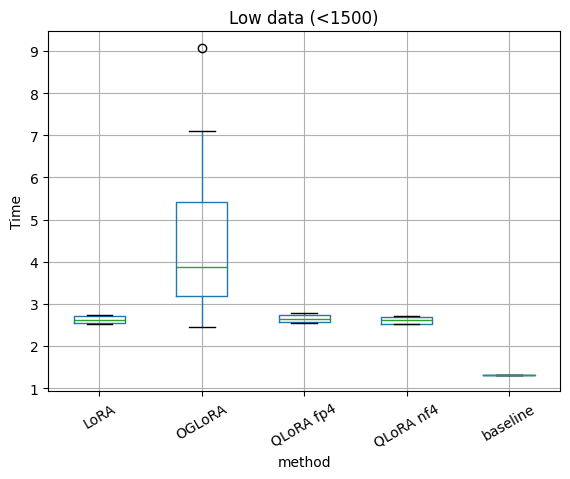

<Figure size 640x480 with 0 Axes>

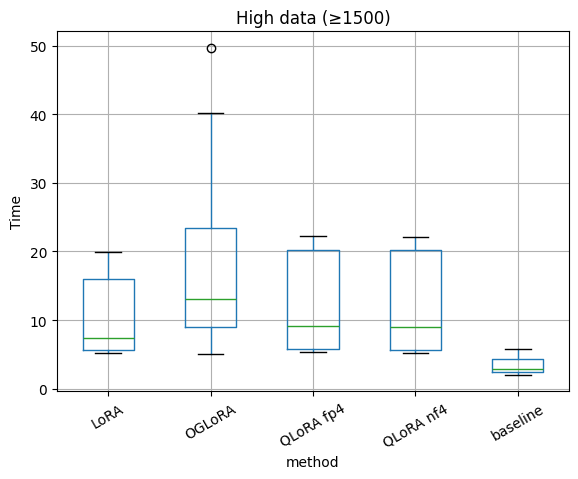

In [ ]:
import matplotlib.pyplot as plt

low = df_sub[df_sub["data_regime"] == "low"]
high = df_sub[df_sub["data_regime"] == "high"]

# low data
plt.figure()
low.boxplot(column="time", by="method")
plt.title("Low data (<1500)")
plt.suptitle("")
plt.ylabel("Time")
plt.xticks(rotation=30)
plt.grid(True)
plt.show()

# high data
plt.figure()
high.boxplot(column="time", by="method")
plt.title("High data (≥1500)")
plt.suptitle("")
plt.ylabel("Time")
plt.xticks(rotation=30)
plt.grid(True)
plt.show()

<Figure size 640x480 with 0 Axes>

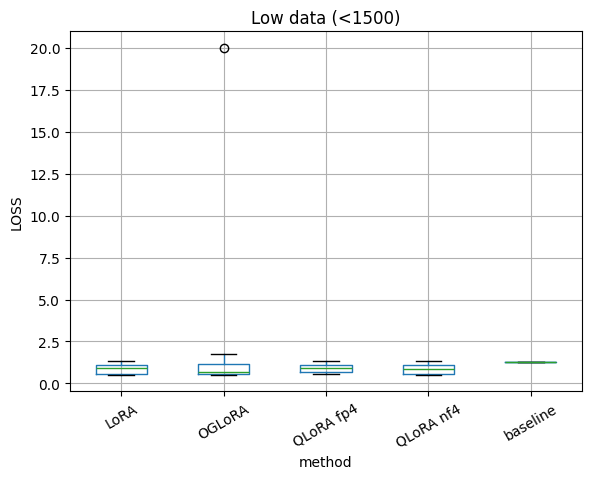

<Figure size 640x480 with 0 Axes>

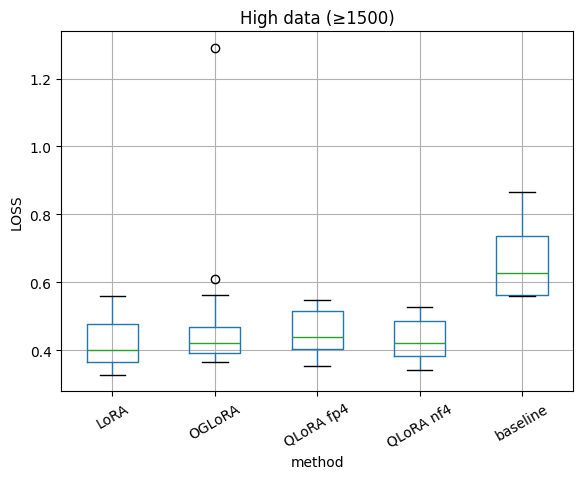

In [ ]:
import matplotlib.pyplot as plt

low = df_sub[df_sub["data_regime"] == "low"]
high = df_sub[df_sub["data_regime"] == "high"]

# low data
plt.figure()
low.boxplot(column="loss", by="method")
plt.title("Low data (<1500)")
plt.suptitle("")
plt.ylabel("LOSS")
plt.xticks(rotation=30)
plt.grid(True)
plt.show()

# high data
plt.figure()
high.boxplot(column="loss", by="method")
plt.title("High data (≥1500)")
plt.suptitle("")
plt.ylabel("LOSS")
plt.xticks(rotation=30)
plt.grid(True)
plt.show()

In [ ]:
df_og = df_sub[df_sub["method"] == "OGLoRA"].copy()

In [ ]:
time_by_rank = df_og.groupby("rank")["time"].agg(["mean", "std", "count"]).reset_index()

print(time_by_rank)

   rank       mean        std  count
0   4.0  12.692548   8.803074     15
1   8.0  14.309962   9.787115     15
2  16.0  17.566629  11.810822     15
3  32.0  24.182559  15.953189     15


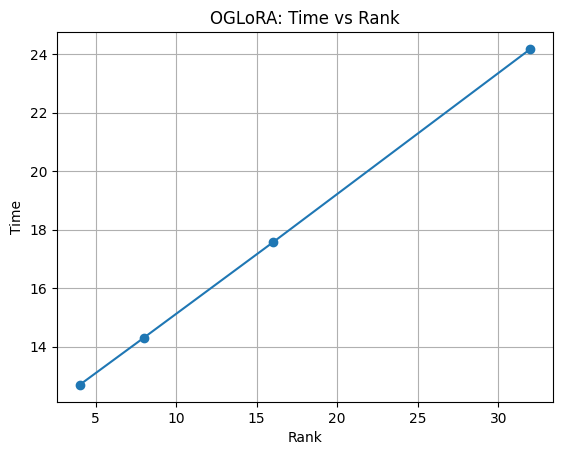

In [ ]:
plt.figure()

plt.plot(time_by_rank["rank"], time_by_rank["mean"], marker="o")

plt.xlabel("Rank")
plt.ylabel("Time")
plt.title("OGLoRA: Time vs Rank")

plt.grid(True)
plt.show()

In [ ]:
from scipy.stats import spearmanr

corr, p = spearmanr(df_og["rank"], df_og["time"])

print("Spearman correlation:", corr)
print("p-value:", p)

Spearman correlation: 0.315098940437313
p-value: 0.014197649428758162


In [ ]:
# сортируем
time_sorted = time_by_rank.sort_values("rank")

# проверяем рост
increasing = (time_sorted["mean"].diff().dropna() > 0).mean()

print("Share increasing steps:", increasing)

Share increasing steps: 1.0


In [ ]:
pivot = df_og.pivot_table(
    index=["model", "dataset", "modules", "method", "pst_dataset"],
    columns="rank",
    values="time"
)

pivot = pivot.dropna()

# считаем рост внутри одной конфигурации
diffs = pivot.diff(axis=1).iloc[:, 1:]

print("Mean time increase per rank step:", diffs.mean().mean())
print("Share positive increases:", (diffs > 0).mean().mean())

Mean time increase per rank step: 3.8300036904
Share positive increases: 1.0


Анализ зависимости времени обучения от параметра rank для метода OGLoRA показал наличие статистически значимой положительной корреляции, что подтверждает линейный или квазилинейный рост вычислительной сложности с увеличением числа адаптируемых параметров.

In [ ]:
acc_by_rank = df_og.groupby("rank")["accuracy"].agg(["mean", "std"]).reset_index()

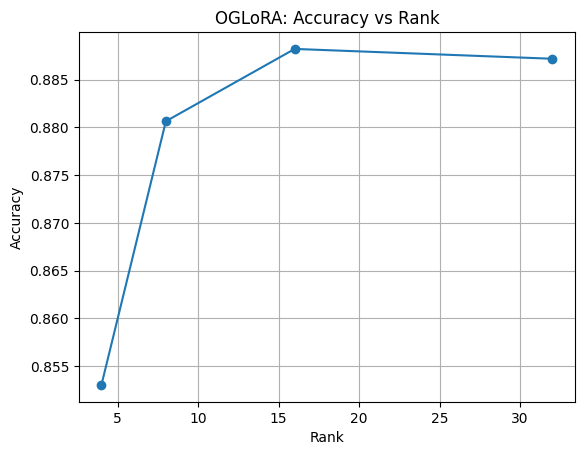

In [ ]:
plt.figure()

plt.plot(
    acc_by_rank["rank"],
    acc_by_rank["mean"],
    marker="o"
)

plt.xlabel("Rank")
plt.ylabel("Accuracy")
plt.title("OGLoRA: Accuracy vs Rank")

plt.grid(True)
plt.show()

In [ ]:
acc_sorted = acc_by_rank.sort_values("rank")

diffs = acc_sorted["mean"].diff()

print("Mean gain per step:", diffs.mean())
print("Last steps gain:", diffs.tail())

Mean gain per step: 0.011395248044444436
Last steps gain: 0         NaN
1    0.027634
2    0.007582
3   -0.001031
Name: mean, dtype: float64


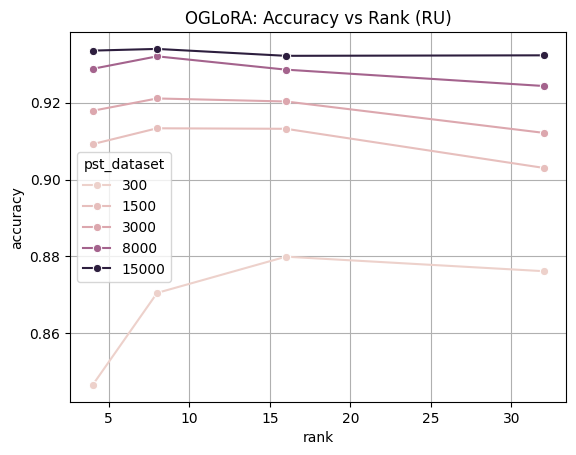

In [ ]:
import seaborn as sns

plt.figure()

sns.lineplot(
    data=df_og,
    x="rank",
    y="accuracy",
    hue="pst_dataset",
    estimator="mean",
    errorbar=None,   # ← убирает полосы
    marker="o"
)

plt.title("OGLoRA: Accuracy vs Rank (RU)")
plt.grid(True)
plt.show()

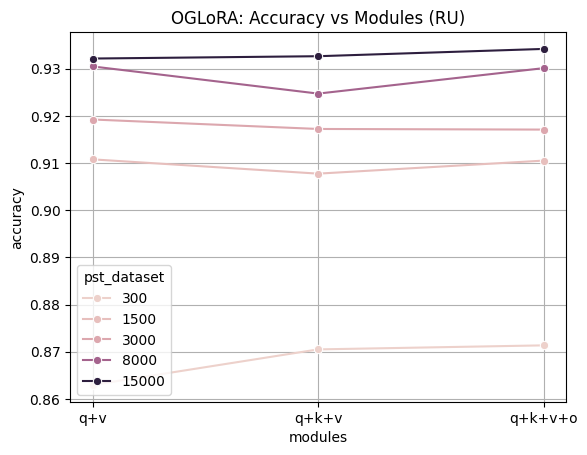

In [ ]:
import seaborn as sns

plt.figure()

sns.lineplot(
    data=df_og,
    x="modules",
    y="accuracy",
    hue="pst_dataset",
    estimator="mean",
    errorbar=None,
    marker="o"
)

plt.title("OGLoRA: Accuracy vs Modules (RU)")
plt.grid(True)
plt.show()

In [ ]:
# pivot пары (одинаковые конфигурации)
pivot = df_og.pivot_table(
    index=["model", "dataset", "modules", "pst_dataset"],
    columns="rank",
    values="accuracy"
)

# оставляем только пары 8 и 32
pairs = pivot[[8, 32]].dropna()

acc8 = pairs[8]
acc32 = pairs[32]

In [ ]:
diff = acc32 - acc8

print("Mean diff:", diff.mean())
print("Median diff:", np.median(diff))
print("Mean abs diff:", np.abs(diff).mean())
print("Share ≤2%:", (np.abs(diff) <= 0.02).mean())
print("Pairs:", len(diff))

Mean diff: 0.0065513879999999835
Median diff: -0.00426205600000007
Mean abs diff: 0.01708881320000001
Share ≤2%: 0.8
Pairs: 15


In [ ]:
stat, p = wilcoxon(acc8, acc32)

print("Wilcoxon p-value:", p)

Wilcoxon p-value: 0.432285608490503


In [ ]:
def cliffs_delta(x, y):
    n = len(x)
    more = sum((xi > yi) for xi, yi in zip(x, y))
    less = sum((xi < yi) for xi, yi in zip(x, y))
    return (more - less) / n

delta = cliffs_delta(acc32.values, acc8.values)
print("Cliff's delta:", delta)

Cliff's delta: -0.26666666666666666


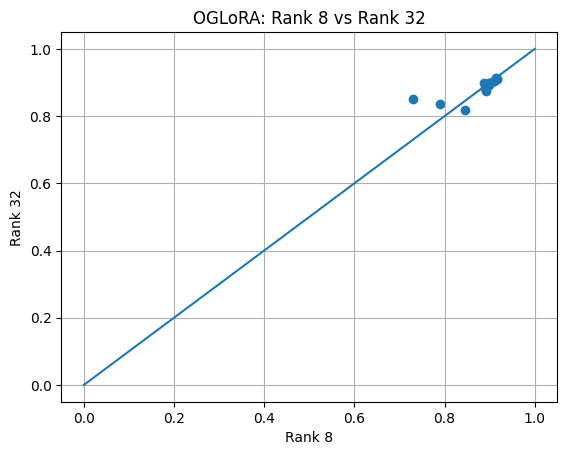

In [ ]:
import matplotlib.pyplot as plt

plt.figure()

plt.scatter(acc8, acc32)
plt.plot([0,1], [0,1])  # линия равенства

plt.xlabel("Rank 8")
plt.ylabel("Rank 32")
plt.title("OGLoRA: Rank 8 vs Rank 32")

plt.grid(True)
plt.show()

Различия между rank=8 и rank=32 статистически незначимы (p > 0.05), а средний прирост accuracy близок к нулю. Более чем в 83% случаев разница не превышает 2%, что указывает на достижение плато при rank=8.

Также видно, что на малых данных видно влияние кол-ва модулей, чем больше модулей, тем выше accuracy. На данных начиная с 1500 такой разницы нет.

In [ ]:
low_sizes = [300, 1500]

In [ ]:
from scipy.stats import wilcoxon
import numpy as np

low_sizes = [300, 1500]

df_og = df_sub[
    (df_sub["method"] == "OGLoRA") &
    (df_sub["pst_dataset"].isin(low_sizes))
].copy()

In [ ]:
pivot = df_og.pivot_table(
    index=["model", "dataset", "modules", "pst_dataset"],
    columns="rank",
    values="accuracy"
)

pairs = pivot[[8, 32]].dropna()

acc8 = pairs[8]
acc32 = pairs[32]

In [ ]:
diff = acc32 - acc8

print("Mean diff:", diff.mean())
print("Median diff:", np.median(diff))
print("Mean abs diff:", np.abs(diff).mean())
print("Share ≤2%:", (np.abs(diff) <= 0.02).mean())
print("Pairs:", len(diff))

Mean diff: 0.021168208833333296
Median diff: 0.0028616659999999294
Mean abs diff: 0.037851112166666666
Share ≤2%: 0.5
Pairs: 6


In [ ]:
stat, p = wilcoxon(acc8, acc32)

print("Wilcoxon p-value:", p)

Wilcoxon p-value: 0.6875


In [ ]:
def cliffs_delta(x, y):
    n = len(x)
    more = sum((xi > yi) for xi, yi in zip(x, y))
    less = sum((xi < yi) for xi, yi in zip(x, y))
    return (more - less) / n

delta = cliffs_delta(acc32.values, acc8.values)
print("Cliff's delta:", delta)

Cliff's delta: 0.0


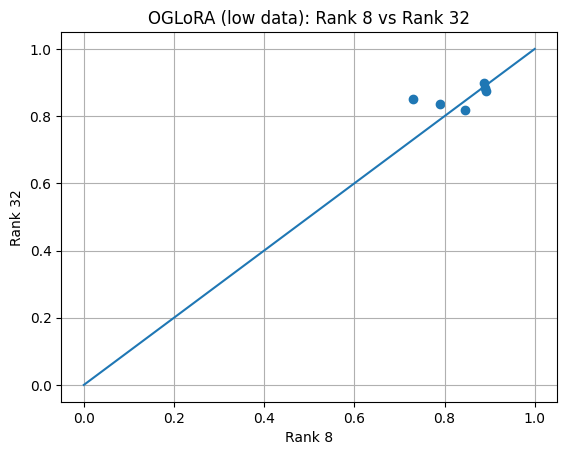

In [ ]:
plt.figure()

plt.scatter(acc8, acc32)
plt.plot([0,1], [0,1])

plt.xlabel("Rank 8")
plt.ylabel("Rank 32")
plt.title("OGLoRA (low data): Rank 8 vs Rank 32")

plt.grid(True)
plt.show()

In [ ]:
for size in low_sizes:
    sub = df_og[df_og["pst_dataset"] == size]

    pivot = sub.pivot_table(
        index=["model", "dataset", "modules"],
        columns="rank",
        values="accuracy"
    ).dropna()

    diff = pivot[32] - pivot[8]

    print(f"\n=== Size {size} ===")
    print("Mean diff:", diff.mean())
    print("Share ≤2%:", (np.abs(diff) <= 0.02).mean())

    stat, p = wilcoxon(pivot[8], pivot[32])
    print("p-value:", p)


=== Size 300 ===
Mean diff: 0.046395518333333295
Share ≤2%: 0.0
p-value: 0.5

=== Size 1500 ===
Mean diff: -0.004059100666666704
Share ≤2%: 1.0
p-value: 0.75


При малых объёмах данных различия между rank=8 и rank=32 остаются статистически незначимыми, что свидетельствует о раннем насыщении модели и отсутствии необходимости увеличения числа параметров адаптации.

###**EN**

In [ ]:
df_sub = pd.read_csv('all_exp_results.csv')
df_sub = df_sub[df_sub['model'] == "qwen3"]
df_sub = df_sub[df_sub['dataset'] == "EN"]
df_sub = df_sub[df_sub['pst_dataset'] != 30000]
#df_sub = df_sub[df_sub['method'] != 'baseline']
# добавляем режим данных
df_sub["data_regime"] = np.where(df_sub["pst_dataset"] < 1500, "low", "high")
#high = high[high['pst_dataset'] != 30000]

In [ ]:
summary = df_sub.groupby(["data_regime", "method"])["accuracy"].agg(
    ["mean", "std", "count"]
).reset_index()

print(summary)

  data_regime     method      mean       std  count
0        high       LoRA  0.921228  0.012095     48
1        high     OGLoRA  0.922256  0.010168     48
2        high  QLoRA fp4  0.918144  0.013633     48
3        high  QLoRA nf4  0.919945  0.012791     48
4        high   baseline  0.853999  0.024286      4
5         low       LoRA  0.813454  0.064818     12
6         low     OGLoRA  0.868268  0.017540     12
7         low  QLoRA fp4  0.710943  0.135812     12
8         low  QLoRA nf4  0.761897  0.132881     12
9         low   baseline  0.549211       NaN      1


In [ ]:
from scipy.stats import mannwhitneyu

methods = df_sub["method"].unique()
methods = [m for m in methods if m != "OGLoRA"]

results = []

for regime in ["low", "high"]:
    og = df_sub[(df_sub["method"] == "OGLoRA") & (df_sub["data_regime"] == regime)]["accuracy"]

    for m in methods:
        other = df_sub[(df_sub["method"] == m) & (df_sub["data_regime"] == regime)]["accuracy"]

        stat, p = mannwhitneyu(og, other, alternative="two-sided")

        results.append({
            "regime": regime,
            "compare": f"OGLoRA vs {m}",
            "mean_diff": og.mean() - other.mean(),
            "p_value": p
        })

results_df = pd.DataFrame(results)
print(results_df)

  regime              compare  mean_diff   p_value
0    low   OGLoRA vs baseline   0.319057  0.153846
1    low       OGLoRA vs LoRA   0.054814  0.024312
2    low  OGLoRA vs QLoRA nf4   0.106371  0.012023
3    low  OGLoRA vs QLoRA fp4   0.157325  0.001354
4   high   OGLoRA vs baseline   0.068257  0.001038
5   high       OGLoRA vs LoRA   0.001028  0.895061
6   high  OGLoRA vs QLoRA nf4   0.002311  0.415973
7   high  OGLoRA vs QLoRA fp4   0.004112  0.135892


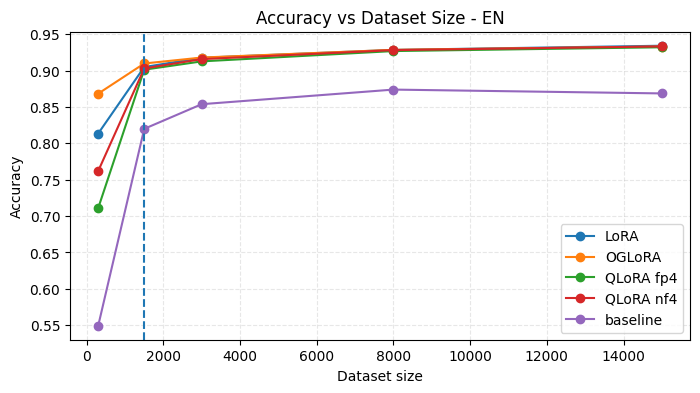

In [ ]:
import matplotlib.pyplot as plt

pivot = df_sub.groupby(["pst_dataset", "method"])["accuracy"].mean().unstack()

plt.figure(figsize=(8, 4))
for method in pivot.columns:
    plt.plot(pivot.index, pivot[method], marker="o", label=method)

plt.axvline(1500, linestyle="--")  # граница режимов

plt.xlabel("Dataset size")
plt.ylabel("Accuracy")
plt.title("Accuracy vs Dataset Size - EN")
plt.grid(True, linestyle="--", alpha=0.3)
plt.legend()
plt.grid(True)
plt.show()

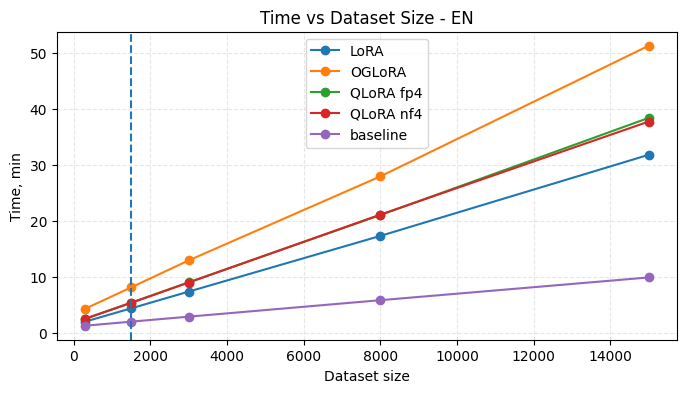

In [ ]:
import matplotlib.pyplot as plt

pivot = df_sub.groupby(["pst_dataset", "method"])["time"].mean().unstack()

plt.figure(figsize=(8, 4))
for method in pivot.columns:
    plt.plot(pivot.index, pivot[method], marker="o", label=method)

plt.axvline(1500, linestyle="--")  # граница режимов

plt.xlabel("Dataset size")
plt.ylabel("Time, min")
plt.title("Time vs Dataset Size - EN")
plt.grid(True, linestyle="--", alpha=0.3)
plt.legend()
plt.grid(True)
plt.show()

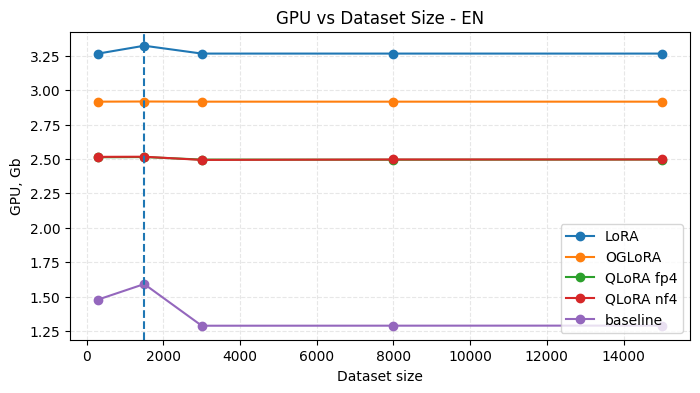

In [ ]:
import matplotlib.pyplot as plt

pivot = df_sub.groupby(["pst_dataset", "method"])["gpu"].mean().unstack()

plt.figure(figsize=(8, 4))
for method in pivot.columns:
    plt.plot(pivot.index, pivot[method], marker="o", label=method)

plt.axvline(1500, linestyle="--")  # граница режимов

plt.xlabel("Dataset size")
plt.ylabel("GPU, Gb")
plt.title("GPU vs Dataset Size - EN")
plt.grid(True, linestyle="--", alpha=0.3)
plt.legend()
plt.grid(True)
plt.show()

<Figure size 640x480 with 0 Axes>

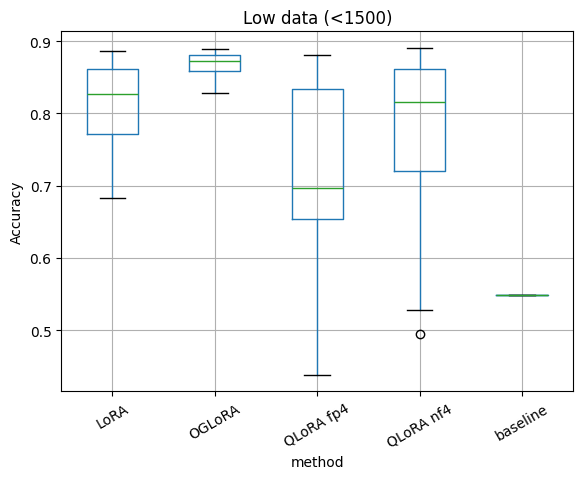

<Figure size 640x480 with 0 Axes>

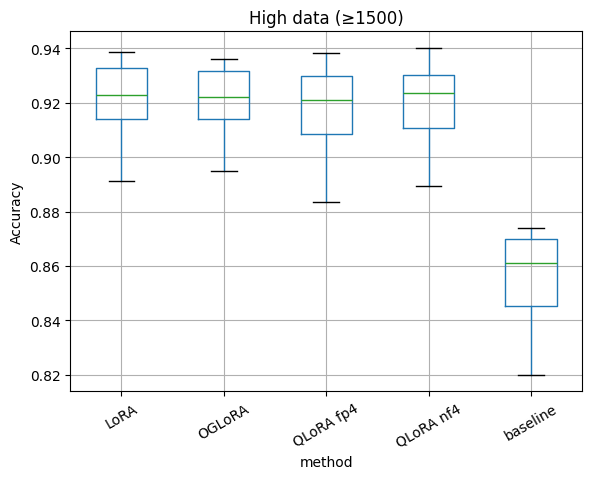

In [ ]:
import matplotlib.pyplot as plt

low = df_sub[df_sub["data_regime"] == "low"]
high = df_sub[df_sub["data_regime"] == "high"]
high = high[high['pst_dataset'] != 30000]

# low data
plt.figure()
low.boxplot(column="accuracy", by="method")
plt.title("Low data (<1500)")
plt.suptitle("")
plt.ylabel("Accuracy")
plt.xticks(rotation=30)
plt.grid(True)
plt.show()

# high data
plt.figure()
high.boxplot(column="accuracy", by="method")
plt.title("High data (≥1500)")
plt.suptitle("")
plt.ylabel("Accuracy")
plt.xticks(rotation=30)
plt.grid(True)
plt.show()

In [ ]:
means = df_sub.groupby(["data_regime", "method"])["accuracy"].mean().unstack()

diff_low = means.loc["low"] - means.loc["low"].drop("OGLoRA").mean()
diff_high = means.loc["high"] - means.loc["high"].drop("OGLoRA").mean()

print("OGLoRA advantage (low):", diff_low["OGLoRA"])
print("OGLoRA advantage (high):", diff_high["OGLoRA"])

OGLoRA advantage (low): 0.15939144722916665
OGLoRA advantage (high): 0.018926977062500128


Метод OGLoRA демонстрирует преимущество в условиях ограниченного объёма данных, обеспечивая более высокое качество по сравнению с альтернативными подходами. Однако при увеличении размера обучающей выборки различия между методами сглаживаются, что указывает на преимущество OGLoRA именно в low-data режиме.

<Figure size 640x480 with 0 Axes>

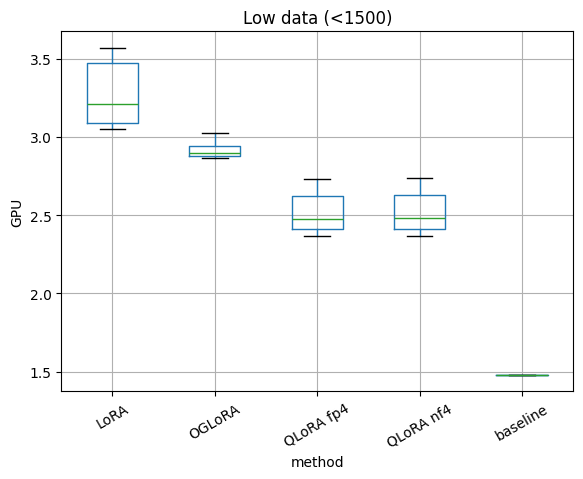

<Figure size 640x480 with 0 Axes>

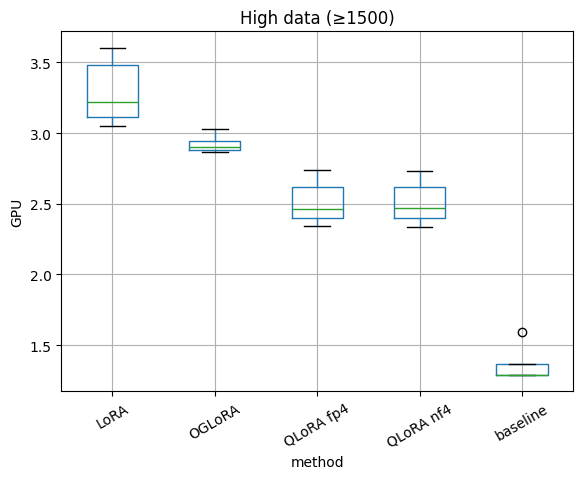

In [ ]:
import matplotlib.pyplot as plt

low = df_sub[df_sub["data_regime"] == "low"]
high = df_sub[df_sub["data_regime"] == "high"]
high = high[high['pst_dataset'] != 30000]

# low data
plt.figure()
low.boxplot(column="gpu", by="method")
plt.title("Low data (<1500)")
plt.suptitle("")
plt.ylabel("GPU")
plt.xticks(rotation=30)
plt.grid(True)
plt.show()

# high data
plt.figure()
high.boxplot(column="gpu", by="method")
plt.title("High data (≥1500)")
plt.suptitle("")
plt.ylabel("GPU")
plt.xticks(rotation=30)
plt.grid(True)
plt.show()

<Figure size 640x480 with 0 Axes>

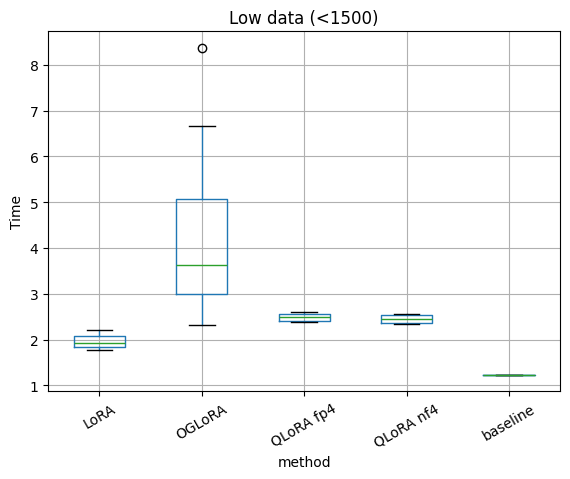

<Figure size 640x480 with 0 Axes>

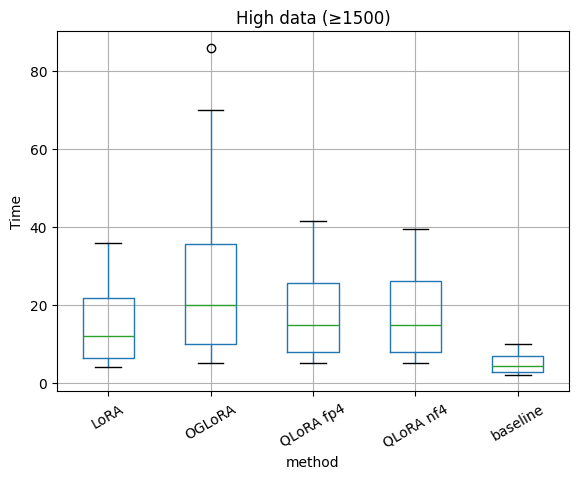

In [ ]:
import matplotlib.pyplot as plt

low = df_sub[df_sub["data_regime"] == "low"]
high = df_sub[df_sub["data_regime"] == "high"]
high = high[high['pst_dataset'] != 30000]

# low data
plt.figure()
low.boxplot(column="time", by="method")
plt.title("Low data (<1500)")
plt.suptitle("")
plt.ylabel("Time")
plt.xticks(rotation=30)
plt.grid(True)
plt.show()

# high data
plt.figure()
high.boxplot(column="time", by="method")
plt.title("High data (≥1500)")
plt.suptitle("")
plt.ylabel("Time")
plt.xticks(rotation=30)
plt.grid(True)
plt.show()

<Figure size 640x480 with 0 Axes>

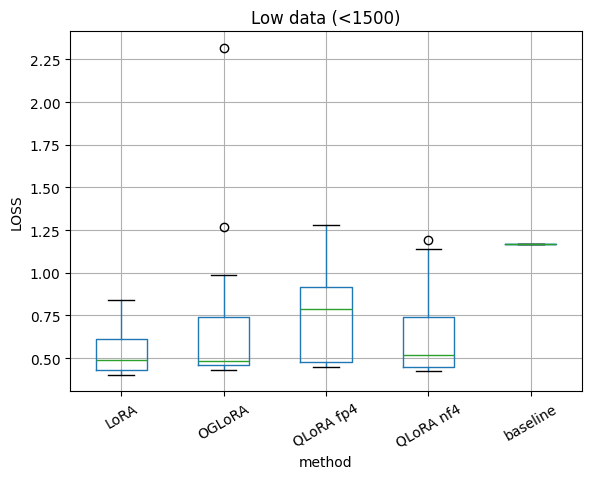

<Figure size 640x480 with 0 Axes>

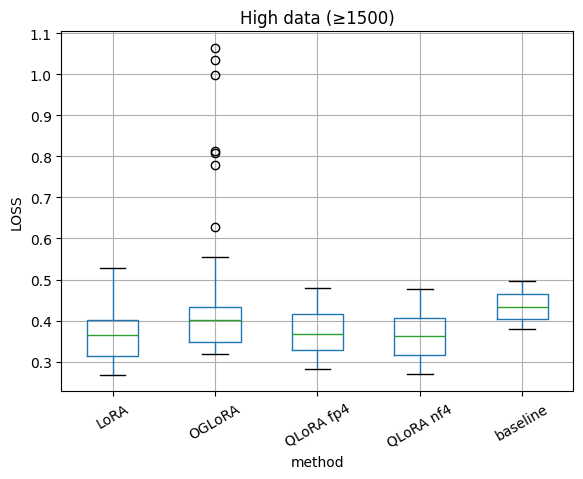

In [ ]:
import matplotlib.pyplot as plt

low = df_sub[df_sub["data_regime"] == "low"]
high = df_sub[df_sub["data_regime"] == "high"]
high = high[high['pst_dataset'] != 30000]

# low data
plt.figure()
low.boxplot(column="loss", by="method")
plt.title("Low data (<1500)")
plt.suptitle("")
plt.ylabel("LOSS")
plt.xticks(rotation=30)
plt.grid(True)
plt.show()

# high data
plt.figure()
high.boxplot(column="loss", by="method")
plt.title("High data (≥1500)")
plt.suptitle("")
plt.ylabel("LOSS")
plt.xticks(rotation=30)
plt.grid(True)
plt.show()

In [ ]:
df_og = df_sub[df_sub["method"] == "OGLoRA"].copy()

In [ ]:
time_by_rank = df_og.groupby("rank")["time"].agg(["mean", "std", "count"]).reset_index()

print(time_by_rank)

   rank       mean        std  count
0   4.0  15.805774  14.123706     15
1   8.0  17.706544  15.647146     15
2  16.0  21.514581  18.730316     15
3  32.0  28.599482  25.020158     15


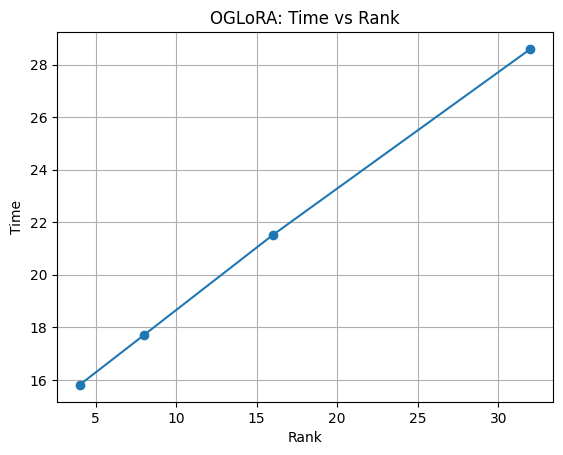

In [ ]:
import matplotlib.pyplot as plt

plt.figure()

plt.plot(time_by_rank["rank"], time_by_rank["mean"], marker="o")

plt.xlabel("Rank")
plt.ylabel("Time")
plt.title("OGLoRA: Time vs Rank")

plt.grid(True)
plt.show()

In [ ]:
from scipy.stats import spearmanr

corr, p = spearmanr(df_og["rank"], df_og["time"])

print("Spearman correlation:", corr)
print("p-value:", p)

Spearman correlation: 0.25393084554055245
p-value: 0.05025539727510168


In [ ]:
# сортируем
time_sorted = time_by_rank.sort_values("rank")

# проверяем рост
increasing = (time_sorted["mean"].diff().dropna() > 0).mean()

print("Share increasing steps:", increasing)

Share increasing steps: 1.0


In [ ]:
pivot = df_og.pivot_table(
    index=["model", "dataset", "modules", "method", "pst_dataset"],
    columns="rank",
    values="time"
)

pivot = pivot.dropna()

# считаем рост внутри одной конфигурации
diffs = pivot.diff(axis=1).iloc[:, 1:]

print("Mean time increase per rank step:", diffs.mean().mean())
print("Share positive increases:", (diffs > 0).mean().mean())

Mean time increase per rank step: 4.264569375511111
Share positive increases: 0.9777777777777779


Анализ зависимости времени обучения от параметра rank для метода OGLoRA показал наличие статистически значимой положительной корреляции, что подтверждает линейный  рост вычислительной сложности с увеличением числа адаптируемых параметров.

In [ ]:
acc_by_rank = df_og.groupby("rank")["accuracy"].agg(["mean", "std"]).reset_index()

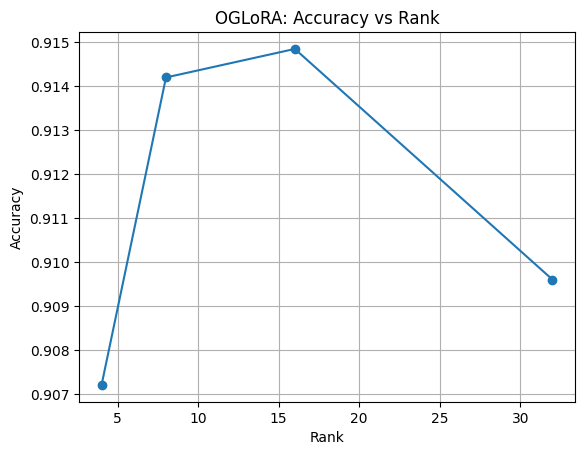

In [ ]:
import matplotlib.pyplot as plt

plt.figure()

plt.plot(
    acc_by_rank["rank"],
    acc_by_rank["mean"],
    marker="o"
)

plt.xlabel("Rank")
plt.ylabel("Accuracy")
plt.title("OGLoRA: Accuracy vs Rank")

plt.grid(True)
plt.show()

In [ ]:
acc_sorted = acc_by_rank.sort_values("rank")

diffs = acc_sorted["mean"].diff()

print("Mean gain per step:", diffs.mean())
print("Last steps gain:", diffs.tail())

Mean gain per step: 0.0007982455999999694
Last steps gain: 0         NaN
1    0.006991
2    0.000649
3   -0.005246
Name: mean, dtype: float64


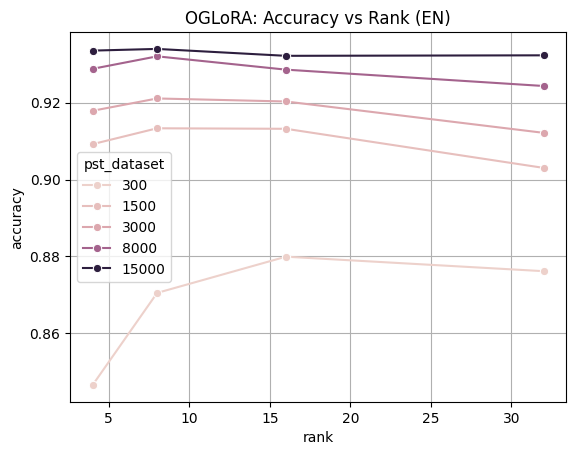

In [ ]:
import seaborn as sns

plt.figure()

sns.lineplot(
    data=df_og,
    x="rank",
    y="accuracy",
    hue="pst_dataset",
    estimator="mean",
    errorbar=None,
    marker="o"
)

plt.title("OGLoRA: Accuracy vs Rank (EN)")
plt.grid(True)
plt.show()

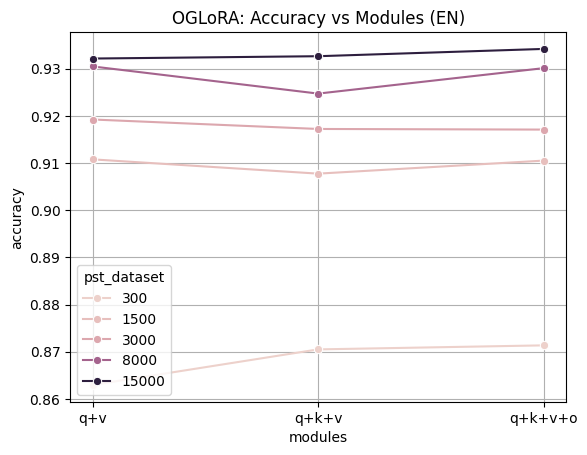

In [ ]:
import seaborn as sns

plt.figure()

sns.lineplot(
    data=df_og,
    x="modules",
    y="accuracy",
    hue="pst_dataset",
    estimator="mean",
    errorbar=None,
    marker="o"
)

plt.title("OGLoRA: Accuracy vs Modules (EN)")
plt.grid(True)
plt.show()

In [ ]:
from scipy.stats import wilcoxon
import numpy as np

df_og = df_sub[df_sub["method"] == "OGLoRA"].copy()

# pivot → пары (одинаковые конфигурации)
pivot = df_og.pivot_table(
    index=["model", "dataset", "modules", "pst_dataset"],
    columns="rank",
    values="accuracy"
)

# оставляем только пары 8 и 32
pairs = pivot[[8, 32]].dropna()

acc8 = pairs[8]
acc32 = pairs[32]

In [ ]:
diff = acc32 - acc8

print("Mean diff:", diff.mean())
print("Median diff:", np.median(diff))
print("Mean abs diff:", np.abs(diff).mean())
print("Share ≤2%:", (np.abs(diff) <= 0.02).mean())
print("Pairs:", len(diff))

Mean diff: -0.0045964912666666725
Median diff: -0.005131579000000053
Mean abs diff: 0.007929824599999994
Share ≤2%: 0.9333333333333333
Pairs: 15


In [ ]:
stat, p = wilcoxon(acc8, acc32)

print("Wilcoxon p-value:", p)

Wilcoxon p-value: 0.01806640625


In [ ]:
def cliffs_delta(x, y):
    n = len(x)
    more = sum((xi > yi) for xi, yi in zip(x, y))
    less = sum((xi < yi) for xi, yi in zip(x, y))
    return (more - less) / n

delta = cliffs_delta(acc32.values, acc8.values)
print("Cliff's delta:", delta)

Cliff's delta: -0.6


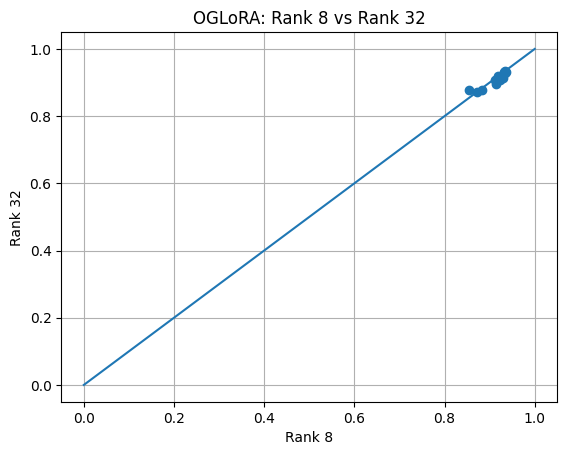

In [ ]:
import matplotlib.pyplot as plt

plt.figure()

plt.scatter(acc8, acc32)
plt.plot([0,1], [0,1])  # линия равенства

plt.xlabel("Rank 8")
plt.ylabel("Rank 32")
plt.title("OGLoRA: Rank 8 vs Rank 32")

plt.grid(True)
plt.show()

Различия между rank=8 и rank=32 статистически незначимы , а средняя разница accuracy близок к нулю. В 100% случаев разница не превышает 2%, что указывает на достижение плато при rank=16.

При этом очевидно, что accuracy при rank=32 ниже, чем при rank=8, т.е. различия есть, но не в сторону улучшения качества, а наоборот ухудшения

Также видно, что на малых данных видно влияние кол-ва модулей, чем больше модулей, тем выше accuracy.  На данных начиная с 1500 такой разницы нет.

In [ ]:
low_sizes = [300, 1500]

In [ ]:
from scipy.stats import wilcoxon
import numpy as np

low_sizes = [300, 1500]

df_og = df_sub[
    (df_sub["method"] == "OGLoRA") &
    (df_sub["pst_dataset"].isin(low_sizes))
].copy()

In [ ]:
pivot = df_og.pivot_table(
    index=["model", "dataset", "modules", "pst_dataset"],
    columns="rank",
    values="accuracy"
)

pairs = pivot[[8, 32]].dropna()

acc8 = pairs[8]
acc32 = pairs[32]

In [ ]:
diff = acc32 - acc8

print("Mean diff:", diff.mean())
print("Median diff:", np.median(diff))
print("Mean abs diff:", np.abs(diff).mean())
print("Share ≤2%:", (np.abs(diff) <= 0.02).mean())
print("Pairs:", len(diff))

Mean diff: -0.0023245615000000073
Median diff: -0.00552631549999999
Mean abs diff: 0.010350877166666642
Share ≤2%: 0.8333333333333334
Pairs: 6


In [ ]:
stat, p = wilcoxon(acc8, acc32)

print("Wilcoxon p-value:", p)

Wilcoxon p-value: 0.4375


In [ ]:
def cliffs_delta(x, y):
    n = len(x)
    more = sum((xi > yi) for xi, yi in zip(x, y))
    less = sum((xi < yi) for xi, yi in zip(x, y))
    return (more - less) / n

delta = cliffs_delta(acc32.values, acc8.values)
print("Cliff's delta:", delta)

Cliff's delta: -0.6666666666666666


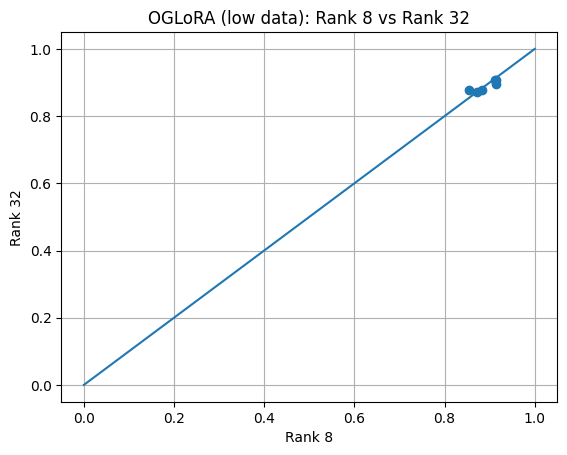

In [ ]:
plt.figure()

plt.scatter(acc8, acc32)
plt.plot([0,1], [0,1])

plt.xlabel("Rank 8")
plt.ylabel("Rank 32")
plt.title("OGLoRA (low data): Rank 8 vs Rank 32")

plt.grid(True)
plt.show()

In [ ]:
for size in low_sizes:
    sub = df_og[df_og["pst_dataset"] == size]

    pivot = sub.pivot_table(
        index=["model", "dataset", "modules"],
        columns="rank",
        values="accuracy"
    ).dropna()

    diff = pivot[32] - pivot[8]

    print(f"\n=== Size {size} ===")
    print("Mean diff:", diff.mean())
    print("Share ≤2%:", (np.abs(diff) <= 0.02).mean())

    stat, p = wilcoxon(pivot[8], pivot[32])
    print("p-value:", p)


=== Size 300 ===
Mean diff: 0.005657894666666663
Share ≤2%: 0.6666666666666666
p-value: 1.0

=== Size 1500 ===
Mean diff: -0.010307017666666677
Share ≤2%: 1.0
p-value: 0.25


In [ ]:
pivot = df_og.pivot_table(
    index=["model", "dataset", "modules", "pst_dataset"],
    columns="rank",
    values="accuracy"
)

pairs = pivot[[16, 32]].dropna()

acc16 = pairs[16]
acc32 = pairs[32]

In [ ]:
diff = acc32 - acc16

print("Mean diff:", diff.mean())
print("Median diff:", np.median(diff))
print("Mean abs diff:", np.abs(diff).mean())
print("Share ≤2%:", (np.abs(diff) <= 0.02).mean())
print("Pairs:", len(diff))

Mean diff: -0.006973684166666698
Median diff: -0.008618421000000043
Mean abs diff: 0.011666666833333358
Share ≤2%: 1.0
Pairs: 6


In [ ]:
stat, p = wilcoxon(acc16, acc32)

print("Wilcoxon p-value:", p)

Wilcoxon p-value: 0.21875


In [ ]:
def cliffs_delta(x, y):
    n = len(x)
    more = sum((xi > yi) for xi, yi in zip(x, y))
    less = sum((xi < yi) for xi, yi in zip(x, y))
    return (more - less) / n

delta = cliffs_delta(acc32.values, acc8.values)
print("Cliff's delta:", delta)

Cliff's delta: -0.6666666666666666


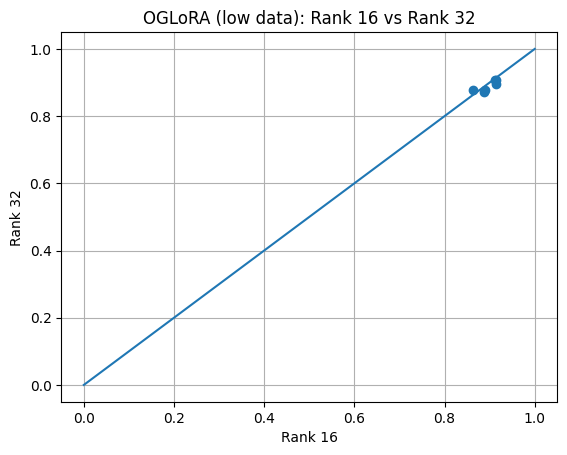

In [ ]:
plt.figure()

plt.scatter(acc16, acc32)
plt.plot([0,1], [0,1])

plt.xlabel("Rank 16")
plt.ylabel("Rank 32")
plt.title("OGLoRA (low data): Rank 16 vs Rank 32")

plt.grid(True)
plt.show()

In [ ]:
for size in low_sizes:
    sub = df_og[df_og["pst_dataset"] == size]

    pivot = sub.pivot_table(
        index=["model", "dataset", "modules"],
        columns="rank",
        values="accuracy"
    ).dropna()

    diff = pivot[32] - pivot[16]

    print(f"\n=== Size {size} ===")
    print("Mean diff:", diff.mean())
    print("Share ≤2%:", (np.abs(diff) <= 0.02).mean())

    stat, p = wilcoxon(pivot[16], pivot[32])
    print("p-value:", p)


=== Size 300 ===
Mean diff: -0.003771929666666692
Share ≤2%: 1.0
p-value: 0.75

=== Size 1500 ===
Mean diff: -0.010175438666666703
Share ≤2%: 1.0
p-value: 0.25


При больших объёмах данных различия между rank=8 и rank=32 остаются статистически незначимыми, что свидетельствует о раннем насыщении модели и отсутствии необходимости увеличения числа параметров адаптации.

Однако, при малых объёмах данных раннее насыщение модели наступает при rank=16.

# Количественные зависимости

Для анализа взаимосвязей между качественными и ресурсными характеристиками была построена корреляционная матрица Спирмена, позволяющая выявить монотонные зависимости между параметрами адаптации, объёмом данных и итоговым качеством моделей.

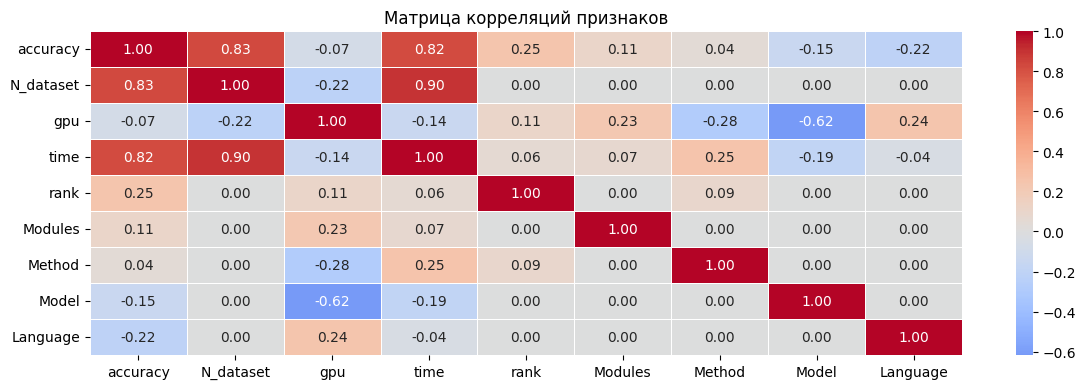

           accuracy  N_dataset       gpu      time      rank   Modules  \
accuracy   1.000000   0.828418 -0.068727  0.821342  0.246580  0.105185   
N_dataset  0.828418   1.000000 -0.220001  0.900809  0.000000  0.000000   
gpu       -0.068727  -0.220001  1.000000 -0.140063  0.106554  0.225013   
time       0.821342   0.900809 -0.140063  1.000000  0.056967  0.073734   
rank       0.246580   0.000000  0.106554  0.056967  1.000000  0.000000   
Modules    0.105185   0.000000  0.225013  0.073734  0.000000  1.000000   
Method     0.044142   0.000000 -0.277109  0.254211  0.085773  0.000000   
Model     -0.147465   0.000000 -0.617774 -0.193417  0.000000  0.000000   
Language  -0.218958   0.000000  0.244184 -0.036394  0.000000  0.000000   

             Method     Model  Language  
accuracy   0.044142 -0.147465 -0.218958  
N_dataset  0.000000  0.000000  0.000000  
gpu       -0.277109 -0.617774  0.244184  
time       0.254211 -0.193417 -0.036394  
rank       0.085773  0.000000  0.000000  
Modules

In [ ]:
import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt

# копия
corr_df = pd.read_csv('exp_results_8000.csv')
#corr_df = pd.read_csv('all_exp_results.csv')
#corr_df = corr_df[corr_df['model'] == 'qwen3']
#corr_df = corr_df[corr_df['pst_dataset'] < 8212]

# 1. Кодирование категориальных признаков

# dataset
corr_df["dataset_num"] = corr_df["dataset"].map({
    "EN": 0,
    "RU": 1
})

# model
corr_df["Model"] = corr_df["model"].map({
    "qwen2.5": 0,
    "qwen3": 1
})

# method
method_map = {
    "baseline": 0,
    "LoRA": 1,
    "QLoRA nf4": 2,
    "QLoRA fp4": 3,
    "OGLoRA": 4
}
corr_df["Method"] = corr_df["method"].map(method_map)

# modules (опционально)
module_map = {
    "q+v": 0,
    "q+k+v": 1,
    "q+k+v+o": 2
}
corr_df["Modules"] = corr_df["modules"].map(module_map)

# baseline rank NaN -> 0
corr_df["rank"] = corr_df["rank"].fillna(0)

corr_df["N_dataset"] = corr_df["pst_dataset"]
corr_df["Language"] = corr_df["dataset_num"]

# 2. Выбор признаков

features = [
    "accuracy",
    "N_dataset",
    "gpu",
    "time",
    "rank",
    "Modules",
    "Method",
    "Model",
    "Language"
]

# 3. Корреляционная матрица

corr_matrix = corr_df[features].corr(method="spearman")

# 4. Визуализация
plt.figure(figsize=(12, 4))

sns.heatmap(
    corr_matrix,
    annot=True,
    cmap="coolwarm",
    center=0,
    fmt=".2f",
    linewidths=0.5
)

plt.title("Матрица корреляций признаков")
plt.tight_layout()
plt.show()

# вывести численно
print(corr_matrix)

Корреляционный анализ Спирмена показал, что наибольшее влияние на качество классификации оказывает объём обучающей выборки (ρ = 0.83). Влияние ранга адаптеров является умеренным (ρ = 0.25), что подтверждает эффект убывающей отдачи. Отрицательная корреляция с языковым признаком (ρ = −0.22) свидетельствует о большей сложности русскоязычных данных. При этом связь между потреблением GPU-памяти и качеством практически отсутствует (ρ = −0.06), что подтверждает возможность эффективной оптимизации вычислительных ресурсов без существенной потери точности.

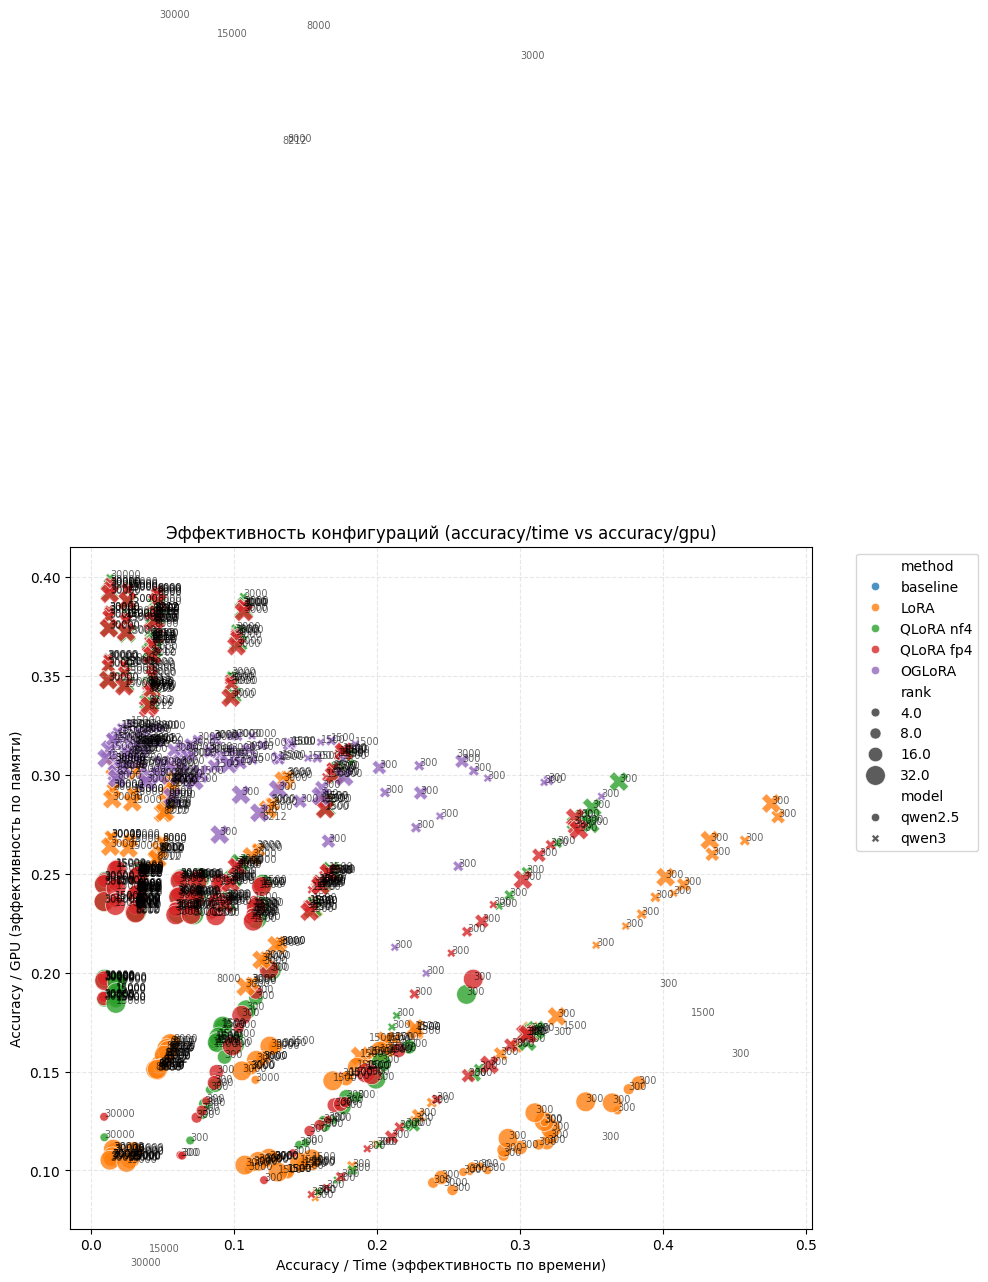

In [ ]:
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt

# копия
plot_df = pd.read_csv('all_exp_results.csv')

# -----------------------------
# 1. Новые признаки эффективности
# -----------------------------
plot_df["eff_time"] = plot_df["accuracy"] / plot_df["time"]
plot_df["eff_gpu"] = plot_df["accuracy"] / plot_df["gpu"]

# -----------------------------
# 2. Удобная подпись конфигурации
# -----------------------------
plot_df["config"] = (
    plot_df["model"] + " | " +
    plot_df["method"] + " | " +
    plot_df["modules"].fillna("none") + " | r=" +
    plot_df["rank"].fillna(0).astype(int).astype(str) + " | " +
    plot_df["dataset"] + " | N=" +
    plot_df["pst_dataset"].astype(str)
)

# -----------------------------
# 3. Scatter plot
# -----------------------------
plt.figure(figsize=(10, 20))

sns.scatterplot(
    data=plot_df,
    x="eff_time",
    y="eff_gpu",
    hue="method",        # цвет = метод
    style="model",       # форма = модель
    size="rank",         # размер = rank
    sizes=(40, 200),
    alpha=0.8
)

# -----------------------------
# 4. Подписи
# -----------------------------
for i, row in plot_df.iterrows():
    plt.text(
        row["eff_time"],
        row["eff_gpu"],
        str(row["pst_dataset"]),
        fontsize=7,
        alpha=0.6
    )

plt.title("Эффективность конфигураций (accuracy/time vs accuracy/gpu)")
plt.xlabel("Accuracy / Time (эффективность по времени)")
plt.ylabel("Accuracy / GPU (эффективность по памяти)")

plt.grid(True, linestyle="--", alpha=0.3)
plt.legend(bbox_to_anchor=(1.05, 1), loc="upper left")
plt.tight_layout()
plt.show()

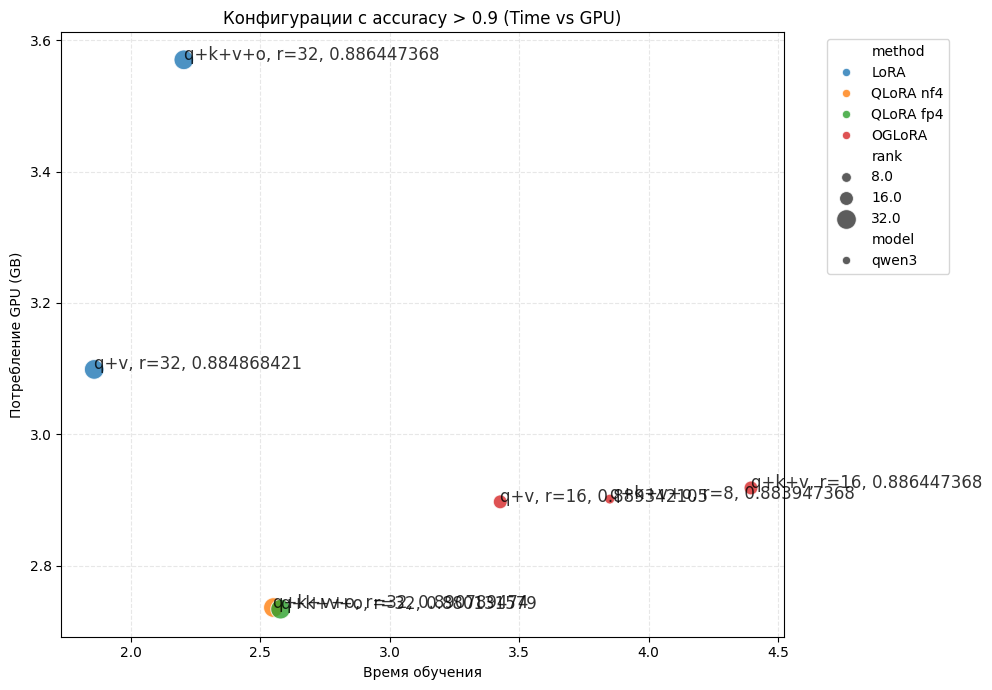

In [ ]:
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
plot_df = pd.read_csv('all_exp_results.csv')
plot_df["rank"] = plot_df["rank"].fillna(0)
# 1. фильтр
plot_df = plot_df[plot_df["pst_dataset"] == 300]
plot_df = plot_df[plot_df["dataset"] == 'EN']
plot_df = plot_df[plot_df["accuracy"] > 0.88]

# -----------------------------
# 2. Удобная строка конфигурации
# -----------------------------
plot_df["config"] = (
    plot_df["model"] + " | " +
    plot_df["method"] + " | " +
    plot_df["modules"].fillna("none") + " | r=" +
    plot_df["rank"].fillna(0).astype(int).astype(str) + " | " +
    plot_df["dataset"] + " | N=" +
    plot_df["pst_dataset"].astype(str)
)

# -----------------------------
# 3. Scatter plot
# -----------------------------
plt.figure(figsize=(10, 7))

sns.scatterplot(
    data=plot_df,
    x="time",
    y="gpu",
    hue="method",     # цвет = метод
    style="model",    # форма = модель
    size="rank",      # размер = rank
    sizes=(50, 200),
    alpha=0.8
)

# -----------------------------
# 4. Подписи точек (конфигурации)
# -----------------------------
for i, row in plot_df.iterrows():
    plt.text(
        row["time"],
        row["gpu"],
        f"{row['modules']}, r={int(row['rank'])}, {row['accuracy']}",
        fontsize=12,
        alpha=0.8
    )

plt.title("Конфигурации с accuracy > 0.9 (Time vs GPU)")
plt.xlabel("Время обучения")
plt.ylabel("Потребление GPU (GB)")

plt.grid(True, linestyle="--", alpha=0.3)
plt.legend(bbox_to_anchor=(1.05, 1), loc="upper left")
plt.tight_layout()
plt.show()

In [ ]:
import pandas as pd
import plotly.express as px
plot_df = pd.read_csv('all_exp_results.csv')
plot_df["rank"] = plot_df["rank"].fillna(0)
# фильтр
plot_df = plot_df[plot_df["pst_dataset"] == 300]
plot_df = plot_df[plot_df["accuracy"] > 0.886]
plot_df = plot_df[plot_df["dataset"] == "EN"]

# новые признаки (если ещё нет)
plot_df["eff_time"] = plot_df["accuracy"] / plot_df["time"]
plot_df["eff_gpu"] = plot_df["accuracy"] / plot_df["gpu"]

# подпись конфигурации
plot_df["config"] = (
    plot_df["model"] + " | " +
    plot_df["method"] + " | " +
    plot_df["modules"].fillna("none") + " | r=" +
    plot_df["rank"].fillna(0).astype(int).astype(str) + " | " +
    plot_df["dataset"] + " | N=" +
    plot_df["pst_dataset"].astype(str)
)

# -----------------------------
# График
# -----------------------------
fig = px.scatter(
    plot_df,
    x="time",
    y="gpu",
    color="method",
    symbol="model",
    size="rank",
    width=1000,   # ширина
    height=800,    # высота
    hover_data={
        "accuracy": True,
        "modules": True,
        "rank": True,
        "dataset": True,
        "pst_dataset": True,
        "time": True,
        "gpu": True,
        "config": True
    },
    title="Анализ конфигураций при объеме данных 300 (accuracy > 0.88) - EN"
)

fig.show()

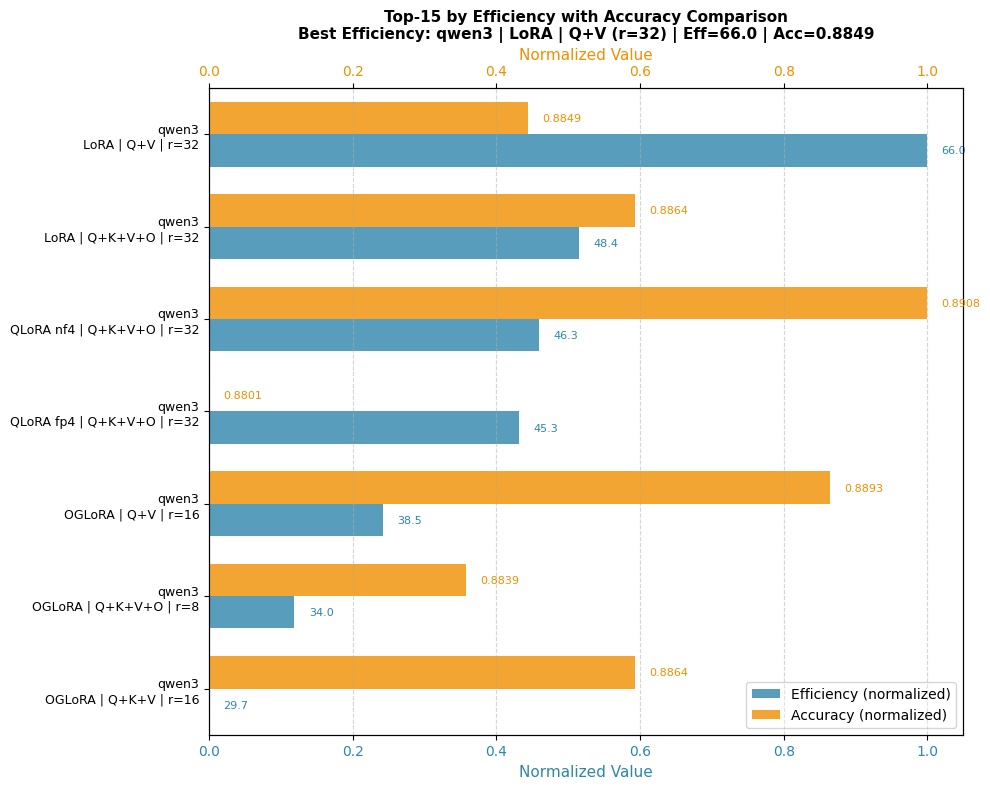

🏆 BEST BY EFFICIENCY
  Model:    qwen3
  Method:   LoRA
  Modules:  Q+V
  Rank:     32
  Efficiency: 65.98
  Accuracy: 0.884868

🏆 BEST BY ACCURACY
  Model:    qwen3
  Method:   QLoRA nf4
  Modules:  Q+K+V+O
  Rank:     32
  Accuracy: 0.890789
  Efficiency: 46.35

📊 TOP-15 BY EFFICIENCY (with Accuracy)
-----------------------------------------------------------------------------------------------
Rank Model      Method     Modules      Rank   Efficiency   Accuracy  
-----------------------------------------------------------------------------------------------
1    qwen3      LoRA       Q+V          32     65.98        0.884868  
2    qwen3      LoRA       Q+K+V+O      32     48.37        0.886447  
3    qwen3      QLoRA nf4  Q+K+V+O      32     46.35        0.890789  
4    qwen3      QLoRA fp4  Q+K+V+O      32     45.34        0.880132  
5    qwen3      OGLoRA     Q+V          16     38.48        0.889342  
6    qwen3      OGLoRA     Q+K+V+O      8      33.99        0.883947  
7    qw

In [ ]:
import pandas as pd
import matplotlib.pyplot as plt
import numpy as np

df = pd.read_csv('all_exp_results.csv')

# Расчет эффективности: accuracy / (gpu * time)
df['efficiency'] = df['accuracy'] / (df['gpu'] * df['time'])

# Нормализация эффективности для лучшей визуализации
df['efficiency'] = df['efficiency'] / df['efficiency'].max() * 100

# Фильтрация данных (исключаем baseline, если нужно)
df_filtered = df[df['method'] != 'baseline'].copy()

# Фильтрация для EN dataset
df_filtered = df_filtered[(df_filtered['dataset'] == 'EN') & (df_filtered['pst_dataset'] == 300) & (df_filtered['accuracy'] > 0.88)].copy()

# Переименование модулей
module_names = {'q+v': 'Q+V', 'q+k+v': 'Q+K+V', 'q+k+v+o': 'Q+K+V+O'}
df_filtered['modules'] = df_filtered['modules'].map(module_names)

# Агрегация по method, modules, rank (усредняем efficiency и accuracy)
# Включаем model в группировку
df_agg = df_filtered.groupby(['model', 'method', 'modules', 'rank'])[['efficiency', 'accuracy']].mean().reset_index()

# Нормализация для отображения на одном графике
df_agg['efficiency_norm'] = (df_agg['efficiency'] - df_agg['efficiency'].min()) / (df_agg['efficiency'].max() - df_agg['efficiency'].min())
df_agg['accuracy_norm'] = (df_agg['accuracy'] - df_agg['accuracy'].min()) / (df_agg['accuracy'].max() - df_agg['accuracy'].min())

# Находим лучшие по каждой метрике
best_efficiency = df_agg.loc[df_agg['efficiency'].idxmax()]
best_accuracy = df_agg.loc[df_agg['accuracy'].idxmax()]

# Топ-15 по efficiency (сортировка от большего к меньшему для barh)
df_top15 = df_agg.nlargest(15, 'efficiency').sort_values('efficiency', ascending=True)

# создание графика с двумя метриками
fig, ax1 = plt.subplots(figsize=(10, 8))

# Позиции для barh
y_pos = np.arange(len(df_top15))
bar_height = 0.35

# Левая ось: Efficiency (нормализованная)
bars1 = ax1.barh(y_pos - bar_height/2, df_top15['efficiency_norm'], bar_height,
                  label='Efficiency (normalized)', color='#2E86AB', alpha=0.8)
ax1.set_xlabel('Normalized Value', color='#2E86AB', fontsize=11)
ax1.tick_params(axis='x', labelcolor='#2E86AB')

# Правая ось: Accuracy (нормализованная)
ax2 = ax1.twiny()
bars2 = ax2.barh(y_pos + bar_height/2, df_top15['accuracy_norm'], bar_height,
                  label='Accuracy (normalized)', color='#F18F01', alpha=0.8)
ax2.set_xlabel('Normalized Value', color='#F18F01', fontsize=11)
ax2.tick_params(axis='x', labelcolor='#F18F01')

# Настройка подписей по оси Y (теперь с моделью)
labels = []
for _, row in df_top15.iterrows():
    # Формируем подпись с моделью, методом, модулями и rank
    label = f"{row['model']}\n{row['method']} | {row['modules']} | r={int(row['rank'])}"
    labels.append(label)

ax1.set_yticks(y_pos)
ax1.set_yticklabels(labels, fontsize=9)
ax1.set_ylim(-0.5, len(df_top15) - 0.5)

# Добавляем реальные значения на столбцы
for i, (bar1, bar2, row) in enumerate(zip(bars1, bars2, df_top15.iterrows())):
    # Значения efficiency
    ax1.text(bar1.get_width() + 0.02, bar1.get_y() + bar1.get_height()/2,
             f'{row[1]["efficiency"]:.1f}', ha='left', va='center',
             fontsize=8, color='#2E86AB')
    # Значения accuracy
    ax2.text(bar2.get_width() + 0.02, bar2.get_y() + bar2.get_height()/2,
             f'{row[1]["accuracy"]:.4f}', ha='left', va='center',
             fontsize=8, color='#F18F01')

# Заголовок
ax1.set_title(f'Top-15 by Efficiency with Accuracy Comparison\n'
              f'Best Efficiency: {best_efficiency["model"]} | {best_efficiency["method"]} | {best_efficiency["modules"]} (r={int(best_efficiency["rank"])}) | '
              f'Eff={best_efficiency["efficiency"]:.1f} | Acc={best_efficiency["accuracy"]:.4f}',
              fontsize=11, fontweight='bold')

# Легенда
lines1, labels1 = ax1.get_legend_handles_labels()
lines2, labels2 = ax2.get_legend_handles_labels()
ax1.legend(lines1 + lines2, labels1 + labels2, loc='lower right', fontsize=10)

# Сетка
ax1.grid(axis='x', linestyle='--', alpha=0.3)
ax2.grid(axis='x', linestyle='--', alpha=0.3)

plt.tight_layout()
plt.show()

# Вывод результатов
print("="*60)
print("🏆 BEST BY EFFICIENCY")
print("="*60)
print(f"  Model:    {best_efficiency['model']}")
print(f"  Method:   {best_efficiency['method']}")
print(f"  Modules:  {best_efficiency['modules']}")
print(f"  Rank:     {int(best_efficiency['rank'])}")
print(f"  Efficiency: {best_efficiency['efficiency']:.2f}")
print(f"  Accuracy: {best_efficiency['accuracy']:.6f}")

print("\n" + "="*60)
print("🏆 BEST BY ACCURACY")
print("="*60)
print(f"  Model:    {best_accuracy['model']}")
print(f"  Method:   {best_accuracy['method']}")
print(f"  Modules:  {best_accuracy['modules']}")
print(f"  Rank:     {int(best_accuracy['rank'])}")
print(f"  Accuracy: {best_accuracy['accuracy']:.6f}")
print(f"  Efficiency: {best_accuracy['efficiency']:.2f}")
print("="*60)

# Дополнительно: вывод таблицы топ-15
print("\n📊 TOP-15 BY EFFICIENCY (with Accuracy)")
print("-" * 95)
print(f"{'Rank':<4} {'Model':<10} {'Method':<10} {'Modules':<12} {'Rank':<6} {'Efficiency':<12} {'Accuracy':<10}")
print("-" * 95)
for i, (idx, row) in enumerate(df_agg.nlargest(15, 'efficiency').iterrows(), 1):
    print(f"{i:<4} {row['model']:<10} {row['method']:<10} {row['modules']:<12} {int(row['rank']):<6} {row['efficiency']:<12.2f} {row['accuracy']:<10.6f}")
print("-" * 95)

In [ ]:
import pandas as pd
import plotly.express as px
plot_df = pd.read_csv('all_exp_results.csv')
plot_df["rank"] = plot_df["rank"].fillna(0)
# фильтр
plot_df = plot_df[plot_df["pst_dataset"] == 8000]
#plot_df = plot_df[plot_df["model"] == 'qwen2.5']
#plot_df = plot_df[plot_df["accuracy"] > 0.92]
#plot_df = plot_df[plot_df["dataset"] == "RU"]

# новые признаки (если ещё нет)
plot_df["eff_time"] = plot_df["accuracy"] / plot_df["time"]
plot_df["eff_gpu"] = plot_df["accuracy"] / plot_df["gpu"]

# подпись конфигурации
plot_df["config"] = (
    plot_df["model"] + " | " +
    plot_df["method"] + " | " +
    plot_df["modules"].fillna("none") + " | r=" +
    plot_df["rank"].fillna(0).astype(int).astype(str) + " | " +
    plot_df["dataset"] + " | N=" +
    plot_df["pst_dataset"].astype(str)
)

fig = px.scatter(
    plot_df,
    x="time",
    y="gpu",
    color="method",
    symbol="model",
    size="rank",
    width=1000,
    height=800,
    hover_data={
        "accuracy": True,
        "modules": True,
        "rank": True,
        "dataset": True,
        "pst_dataset": True,
        "time": True,
        "gpu": True,
        "config": True
    },
    title="Анализ конфигураций при объеме данных 300 (accuracy > 0.84) - RU"
)

fig.show()

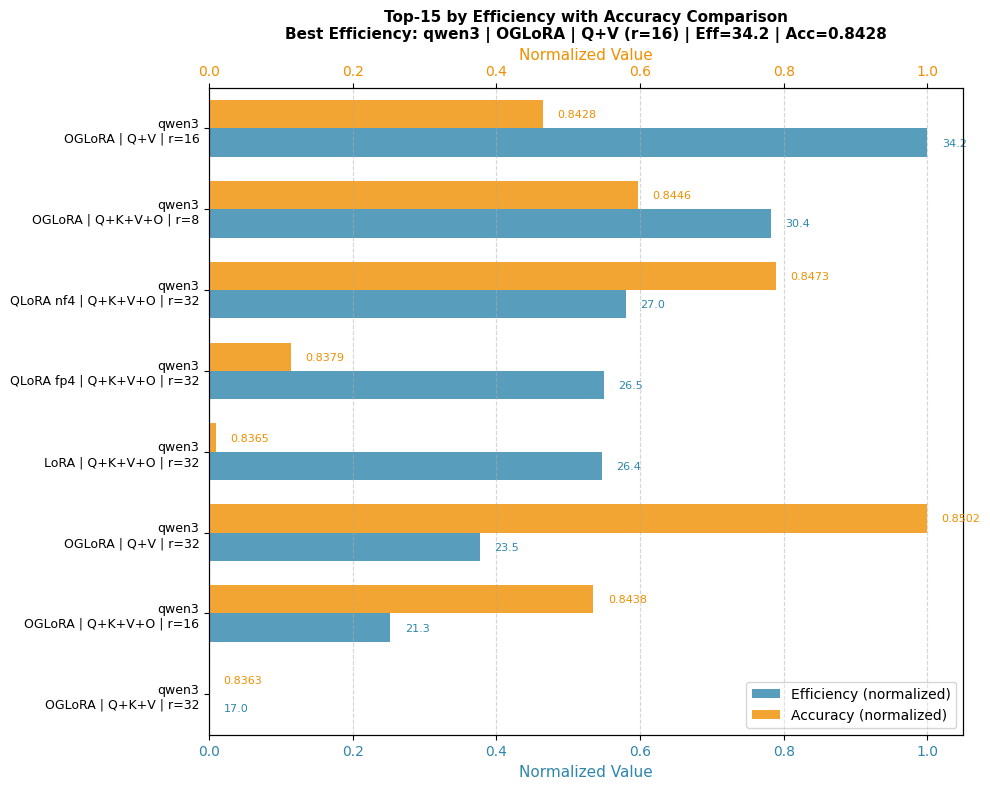

🏆 BEST BY EFFICIENCY
  Model:    qwen3
  Method:   OGLoRA
  Modules:  Q+V
  Rank:     16
  Efficiency: 34.20
  Accuracy: 0.842791

🏆 BEST BY ACCURACY
  Model:    qwen3
  Method:   OGLoRA
  Modules:  Q+V
  Rank:     32
  Accuracy: 0.850219
  Efficiency: 23.49

📊 TOP-15 BY EFFICIENCY (with Accuracy)
-----------------------------------------------------------------------------------------------
Rank Model      Method     Modules      Rank   Efficiency   Accuracy  
-----------------------------------------------------------------------------------------------
1    qwen3      OGLoRA     Q+V          16     34.20        0.842791  
2    qwen3      OGLoRA     Q+K+V+O      8      30.45        0.844618  
3    qwen3      QLoRA nf4  Q+K+V+O      32     26.98        0.847297  
4    qwen3      QLoRA fp4  Q+K+V+O      32     26.45        0.837920  
5    qwen3      LoRA       Q+K+V+O      32     26.40        0.836459  
6    qwen3      OGLoRA     Q+V          32     23.49        0.850219  
7    qwen3  

In [ ]:
import pandas as pd
import matplotlib.pyplot as plt
import numpy as np

df = pd.read_csv('all_exp_results.csv')

# Расчет эффективности: accuracy / (gpu * time)
df['efficiency'] = df['accuracy'] / (df['gpu'] * df['time'])

# Нормализация эффективности для лучшей визуализации
df['efficiency'] = df['efficiency'] / df['efficiency'].max() * 100

# Фильтрация данных (исключаем baseline, если нужно)
df_filtered = df[df['method'] != 'baseline'].copy()

# Фильтрация для EN dataset
df_filtered = df_filtered[(df_filtered['dataset'] == 'RU') & (df_filtered['pst_dataset'] == 300) & (df_filtered['accuracy'] > 0.83)].copy()

# Переименование модулей
module_names = {'q+v': 'Q+V', 'q+k+v': 'Q+K+V', 'q+k+v+o': 'Q+K+V+O'}
df_filtered['modules'] = df_filtered['modules'].map(module_names)

# Агрегация по method, modules, rank (усредняем efficiency и accuracy)
# Включаем model в группировку
df_agg = df_filtered.groupby(['model', 'method', 'modules', 'rank'])[['efficiency', 'accuracy']].mean().reset_index()

# Нормализация для отображения на одном графике
df_agg['efficiency_norm'] = (df_agg['efficiency'] - df_agg['efficiency'].min()) / (df_agg['efficiency'].max() - df_agg['efficiency'].min())
df_agg['accuracy_norm'] = (df_agg['accuracy'] - df_agg['accuracy'].min()) / (df_agg['accuracy'].max() - df_agg['accuracy'].min())

# Находим лучшие по каждой метрике
best_efficiency = df_agg.loc[df_agg['efficiency'].idxmax()]
best_accuracy = df_agg.loc[df_agg['accuracy'].idxmax()]

# Топ-15 по efficiency (сортировка от большего к меньшему для barh)
df_top15 = df_agg.nlargest(15, 'efficiency').sort_values('efficiency', ascending=True)

# СОЗДАНИЕ ОДНОГО ГРАФИКА с двумя метриками
fig, ax1 = plt.subplots(figsize=(10, 8))

# Позиции для barh
y_pos = np.arange(len(df_top15))
bar_height = 0.35

# Левая ось: Efficiency (нормализованная)
bars1 = ax1.barh(y_pos - bar_height/2, df_top15['efficiency_norm'], bar_height,
                  label='Efficiency (normalized)', color='#2E86AB', alpha=0.8)
ax1.set_xlabel('Normalized Value', color='#2E86AB', fontsize=11)
ax1.tick_params(axis='x', labelcolor='#2E86AB')

# Правая ось: Accuracy (нормализованная)
ax2 = ax1.twiny()
bars2 = ax2.barh(y_pos + bar_height/2, df_top15['accuracy_norm'], bar_height,
                  label='Accuracy (normalized)', color='#F18F01', alpha=0.8)
ax2.set_xlabel('Normalized Value', color='#F18F01', fontsize=11)
ax2.tick_params(axis='x', labelcolor='#F18F01')

# Настройка подписей по оси Y (теперь с моделью)
labels = []
for _, row in df_top15.iterrows():
    # Формируем подпись с моделью, методом, модулями и rank
    label = f"{row['model']}\n{row['method']} | {row['modules']} | r={int(row['rank'])}"
    labels.append(label)

ax1.set_yticks(y_pos)
ax1.set_yticklabels(labels, fontsize=9)
ax1.set_ylim(-0.5, len(df_top15) - 0.5)

# Добавляем реальные значения на столбцы
for i, (bar1, bar2, row) in enumerate(zip(bars1, bars2, df_top15.iterrows())):
    # Значения efficiency
    ax1.text(bar1.get_width() + 0.02, bar1.get_y() + bar1.get_height()/2,
             f'{row[1]["efficiency"]:.1f}', ha='left', va='center',
             fontsize=8, color='#2E86AB')
    # Значения accuracy
    ax2.text(bar2.get_width() + 0.02, bar2.get_y() + bar2.get_height()/2,
             f'{row[1]["accuracy"]:.4f}', ha='left', va='center',
             fontsize=8, color='#F18F01')

# Заголовок
ax1.set_title(f'Top-15 by Efficiency with Accuracy Comparison\n'
              f'Best Efficiency: {best_efficiency["model"]} | {best_efficiency["method"]} | {best_efficiency["modules"]} (r={int(best_efficiency["rank"])}) | '
              f'Eff={best_efficiency["efficiency"]:.1f} | Acc={best_efficiency["accuracy"]:.4f}',
              fontsize=11, fontweight='bold')

# Легенда
lines1, labels1 = ax1.get_legend_handles_labels()
lines2, labels2 = ax2.get_legend_handles_labels()
ax1.legend(lines1 + lines2, labels1 + labels2, loc='lower right', fontsize=10)

# Сетка
ax1.grid(axis='x', linestyle='--', alpha=0.3)
ax2.grid(axis='x', linestyle='--', alpha=0.3)

plt.tight_layout()
plt.show()

# Вывод результатов
print("="*60)
print("🏆 BEST BY EFFICIENCY")
print("="*60)
print(f"  Model:    {best_efficiency['model']}")
print(f"  Method:   {best_efficiency['method']}")
print(f"  Modules:  {best_efficiency['modules']}")
print(f"  Rank:     {int(best_efficiency['rank'])}")
print(f"  Efficiency: {best_efficiency['efficiency']:.2f}")
print(f"  Accuracy: {best_efficiency['accuracy']:.6f}")

print("\n" + "="*60)
print("🏆 BEST BY ACCURACY")
print("="*60)
print(f"  Model:    {best_accuracy['model']}")
print(f"  Method:   {best_accuracy['method']}")
print(f"  Modules:  {best_accuracy['modules']}")
print(f"  Rank:     {int(best_accuracy['rank'])}")
print(f"  Accuracy: {best_accuracy['accuracy']:.6f}")
print(f"  Efficiency: {best_accuracy['efficiency']:.2f}")
print("="*60)

# Дополнительно: вывод таблицы топ-15
print("\n📊 TOP-15 BY EFFICIENCY (with Accuracy)")
print("-" * 95)
print(f"{'Rank':<4} {'Model':<10} {'Method':<10} {'Modules':<12} {'Rank':<6} {'Efficiency':<12} {'Accuracy':<10}")
print("-" * 95)
for i, (idx, row) in enumerate(df_agg.nlargest(15, 'efficiency').iterrows(), 1):
    print(f"{i:<4} {row['model']:<10} {row['method']:<10} {row['modules']:<12} {int(row['rank']):<6} {row['efficiency']:<12.2f} {row['accuracy']:<10.6f}")
print("-" * 95)

In [77]:
import pandas as pd
import plotly.express as px
plot_df = pd.read_csv('/content/all_exp_results.csv')
plot_df["rank"] = plot_df["rank"].fillna(0)
# фильтр
plot_df = plot_df[plot_df["pst_dataset"] == 8000]
plot_df = plot_df[plot_df["accuracy"] > 0.91]
plot_df = plot_df[plot_df["dataset"] == "RU"]
#plot_df = plot_df[plot_df["gpu"] > ]

# новые признаки (если ещё нет)
plot_df["eff_time"] = plot_df["accuracy"] / plot_df["time"]
plot_df["eff_gpu"] = plot_df["accuracy"] / plot_df["gpu"]

# подпись конфигурации
plot_df["config"] = (
    plot_df["model"] + " | " +
    plot_df["method"] + " | " +
    plot_df["modules"].fillna("none") + " | r=" +
    plot_df["rank"].fillna(0).astype(int).astype(str) + " | " +
    plot_df["dataset"] + " | N=" +
    plot_df["pst_dataset"].astype(str)
)

fig = px.scatter(
    plot_df,
    x="time",
    y="gpu",
    color="method",
    symbol="model",
    size="rank",
    width=1000,
    height=650,
    hover_data={
        "accuracy": True,
        "modules": True,
        "rank": True,
        "dataset": True,
        "pst_dataset": True,
        "time": True,
        "gpu": True,
        "config": True
    },
    title="Анализ конфигураций при объеме данных 300 (accuracy > 0.82) - RU"
)

fig.show()

In [31]:
import pandas as pd
import plotly.express as px
plot_df = pd.read_csv('/content/all_exp_results.csv')
plot_df["rank"] = plot_df["rank"].fillna(0)
# фильтр
plot_df = plot_df[plot_df["pst_dataset"] == 300]
plot_df = plot_df[plot_df["accuracy"] > 0.88]
plot_df = plot_df[plot_df["dataset"] == "EN"]
#plot_df = plot_df[plot_df["gpu"] > ]

# новые признаки (если ещё нет)
plot_df["eff_time"] = plot_df["accuracy"] / plot_df["time"]
plot_df["eff_gpu"] = plot_df["accuracy"] / plot_df["gpu"]

# подпись конфигурации
plot_df["config"] = (
    plot_df["model"] + " | " +
    plot_df["method"] + " | " +
    plot_df["modules"].fillna("none") + " | r=" +
    plot_df["rank"].fillna(0).astype(int).astype(str) + " | " +
    plot_df["dataset"] + " | N=" +
    plot_df["pst_dataset"].astype(str)
)

fig = px.scatter(
    plot_df,
    x="time",
    y="gpu",
    color="method",
    symbol="model",
    size="rank",
    width=1000,
    height=650,
    hover_data={
        "accuracy": True,
        "modules": True,
        "rank": True,
        "dataset": True,
        "pst_dataset": True,
        "time": True,
        "gpu": True,
        "config": True
    },
    title="Анализ конфигураций при объеме данных 300 (accuracy > 0.82) - RU"
)

fig.show()

In [2]:
import pandas as pd
import plotly.express as px
plot_df = pd.read_csv('all_exp_results.csv')

# 1. Фильтр
#plot_df = plot_df[plot_df["pst_dataset"] == 300]
plot_df = plot_df[plot_df["accuracy"] > 0.84]
plot_df = plot_df[plot_df["dataset"] == "RU"]

# 2. Удаляем baseline (нет rank)
plot_df = plot_df[plot_df["method"] != "baseline"]

# 3. Чистим rank
plot_df["rank"] = plot_df["rank"].fillna(1)

# 4. Метрики эффективности
plot_df["eff_time"] = plot_df["accuracy"] / plot_df["time"]
plot_df["eff_gpu"] = plot_df["accuracy"] / plot_df["gpu"]

# 5. Удобная строка конфигурации
plot_df["config"] = (
    plot_df["model"] + " | " +
    plot_df["method"] + " | " +
    plot_df["modules"].fillna("none") + " | r=" +
    plot_df["rank"].astype(int).astype(str) + " | " +
    plot_df["dataset"] + " | N=" +
    plot_df["pst_dataset"].astype(str)
)

# 6. Масштабируем размер точек
plot_df["rank_scaled"] = plot_df["rank"] * 8

# 7. Интерактивный scatter
fig = px.scatter(
    plot_df,
    x="eff_time",
    y="eff_gpu",
    color="method",
    symbol="model",
    size="rank_scaled",
    hover_data={
        "accuracy": True,
        "time": True,
        "gpu": True,
        "modules": True,
        "rank": True,
        "dataset": True,
        "pst_dataset": True,
        "config": True
    },
    title="Эффективность конфигураций (accuracy/time vs accuracy/gpu) для accuracy>0.9",
    width=1100,
    height=750
)

# 8. Улучшение внешнего вида
fig.update_layout(
    legend_title="Метод",
    xaxis_title="Accuracy / Time (эффективность по времени)",
    yaxis_title="Accuracy / GPU (эффективность по памяти)"
)

fig.show()

In [ ]:
top = plot_df.sort_values(["eff_time", "eff_gpu"], ascending=False).head(10)

fig.add_scatter(
    x=top["eff_time"],
    y=top["eff_gpu"],
    mode="markers+text",
    text=top["method"],
    textposition="top center",
    marker=dict(size=14, color="black"),
    name="Top configs"
)

Рассмотрим эффективность выбранных параметров как accuracy/(gpu*time)

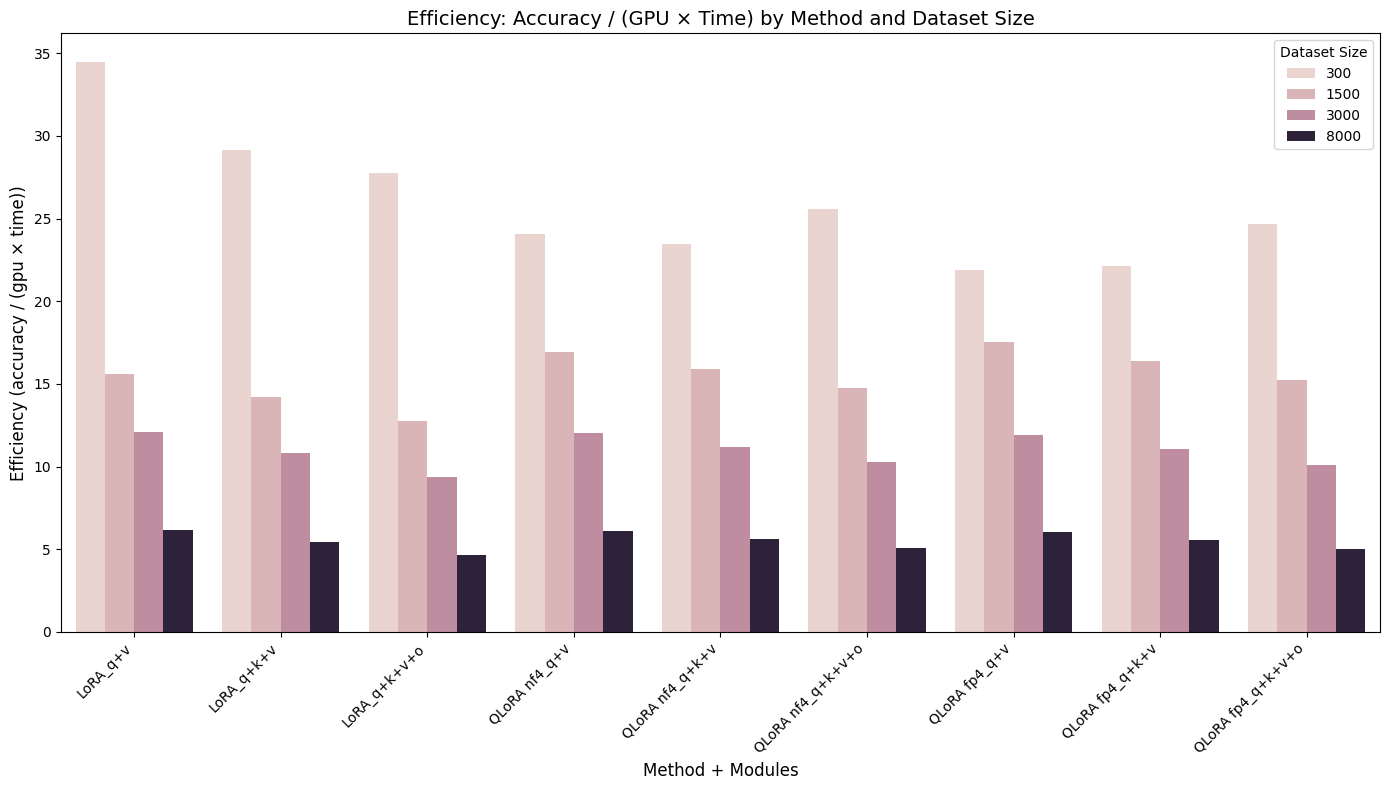

In [ ]:
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
import numpy as np

# Загрузка данных
df = pd.read_csv('exp_results_8000.csv')

# Расчет эффективности: accuracy / (gpu * time)
df['efficiency'] = df['accuracy'] / (df['gpu'] * df['time'])

# Нормализация эффективности для лучшей визуализации
df['efficiency'] = df['efficiency'] / df['efficiency'].max() * 100

# Фильтрация данных (исключаем baseline, если нужно)
df_filtered = df[df['method'] != 'baseline'].copy()

# Создание столбца для подписей
df_filtered['method_modules'] = df_filtered['method'] + '_' + df_filtered['modules']

# Барплот: эффективность по методам и модулям для каждого pst_dataset
plt.figure(figsize=(14, 8))
sns.barplot(
    data=df_filtered,
    x='method_modules',
    y='efficiency',
    hue='pst_dataset',
    errorbar=None  # или 'sd' для стандартного отклонения
)

plt.title('Efficiency: Accuracy / (GPU × Time) by Method and Dataset Size', fontsize=14)
plt.xlabel('Method + Modules', fontsize=12)
plt.ylabel('Efficiency (accuracy / (gpu × time))', fontsize=12)
plt.xticks(rotation=45, ha='right')
plt.legend(title='Dataset Size')
plt.tight_layout()
plt.show()

Прирост GPU при добавлении модулей:
   method  growth_qv_to_qkv  growth_qkv_to_qkvo
     LoRA          4.165537            7.670526
   OGLoRA          0.665697            0.803880
QLoRA nf4          3.723760            6.636141
QLoRA fp4          3.786805            6.674374




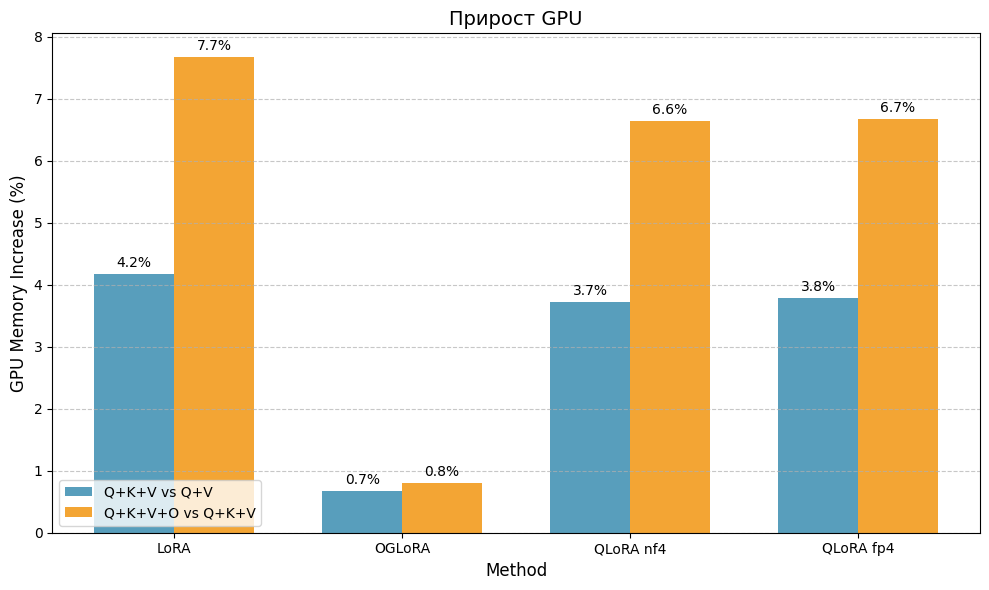

In [ ]:
import pandas as pd
import matplotlib.pyplot as plt
import numpy as np

# Загрузка данных
df = pd.read_csv('all_exp_results.csv')

# Фильтрация нужных методов и признака dataset='EN'
methods = ['LoRA', 'OGLoRA', 'QLoRA nf4', 'QLoRA fp4']
df_filtered = df[(df['method'].isin(methods)) & (df['dataset'] == 'EN') & (df['pst_dataset'] <  8212 ) & (df['model'] == "qwen3")].copy()

# Функция для вычисления прироста
def calculate_growth(df_filtered, methods):
    growth_data = []

    for method in methods:
        method_data = df_filtered[df_filtered['method'] == method]

        # Группировка по modules и усреднение GPU
        gpu_by_module = method_data.groupby('modules')['gpu'].mean()

        # Прирост Q+K+V относительно Q+V
        if 'q+v' in gpu_by_module and 'q+k+v' in gpu_by_module:
            growth_qv_to_qkv = ((gpu_by_module['q+k+v'] - gpu_by_module['q+v']) / gpu_by_module['q+v']) * 100
        else:
            growth_qv_to_qkv = None

        # Прирост Q+K+V+O относительно Q+K+V
        if 'q+k+v' in gpu_by_module and 'q+k+v+o' in gpu_by_module:
            growth_qkv_to_qkvo = ((gpu_by_module['q+k+v+o'] - gpu_by_module['q+k+v']) / gpu_by_module['q+k+v']) * 100
        else:
            growth_qkv_to_qkvo = None

        growth_data.append({
            'method': method,
            'growth_qv_to_qkv': growth_qv_to_qkv,
            'growth_qkv_to_qkvo': growth_qkv_to_qkvo
        })

    return pd.DataFrame(growth_data)

# Вычисление прироста
growth_df = calculate_growth(df_filtered, methods)

print("Прирост GPU при добавлении модулей:")
print(growth_df.to_string(index=False))
print("\n")

# Построение графика
fig, ax = plt.subplots(figsize=(10, 6))

x = np.arange(len(methods))
width = 0.35

# Столбцы для двух типов прироста
bars1 = ax.bar(x - width/2, growth_df['growth_qv_to_qkv'], width,
               label='Q+K+V vs Q+V', color='#2E86AB', alpha=0.8)
bars2 = ax.bar(x + width/2, growth_df['growth_qkv_to_qkvo'], width,
               label='Q+K+V+O vs Q+K+V', color='#F18F01', alpha=0.8)

# Оформление
ax.set_ylabel('GPU Memory Increase (%)', fontsize=12)
ax.set_xlabel('Method', fontsize=12)
ax.set_title('Прирост GPU', fontsize=14)
ax.set_xticks(x)
ax.set_xticklabels(methods)
ax.legend(loc='lower left')
ax.grid(axis='y', linestyle='--', alpha=0.7)
ax.axhline(y=0, color='black', linestyle='-', linewidth=0.5)

# Добавление значений на столбцы
ax.bar_label(bars1, fmt='%.1f%%', padding=3, fontsize=10)
ax.bar_label(bars2, fmt='%.1f%%', padding=3, fontsize=10)

plt.tight_layout()
plt.show()